In [2]:
# Make `import functions` load the project's models/functions.py, not the unrelated 'functions'
# package from site-packages. Searches upward from the notebook's folder, so it works after a clone.
import sys
from pathlib import Path
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'models' / 'functions.py').exists())
sys.path.insert(0, str(_root / 'models'))

In [3]:
import numpy as np
import pandas as pd 
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from keras_tuner.tuners import RandomSearch
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap
import os 
import seaborn as sns 
import functions 
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l1
import plotly.express as px
# from dash.dependencies import Input, Output
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from threading import Timer


In [134]:
# Reload the functions module in case it was already imported before recent edits
import importlib
import functions
importlib.reload(functions)

<module 'functions' from 'c:\\Users\\xuexi\\OneDrive\\桌面\\Projects_Desjardin\\functions.py'>

## 3 Classical momentum strategies - Benchmark 

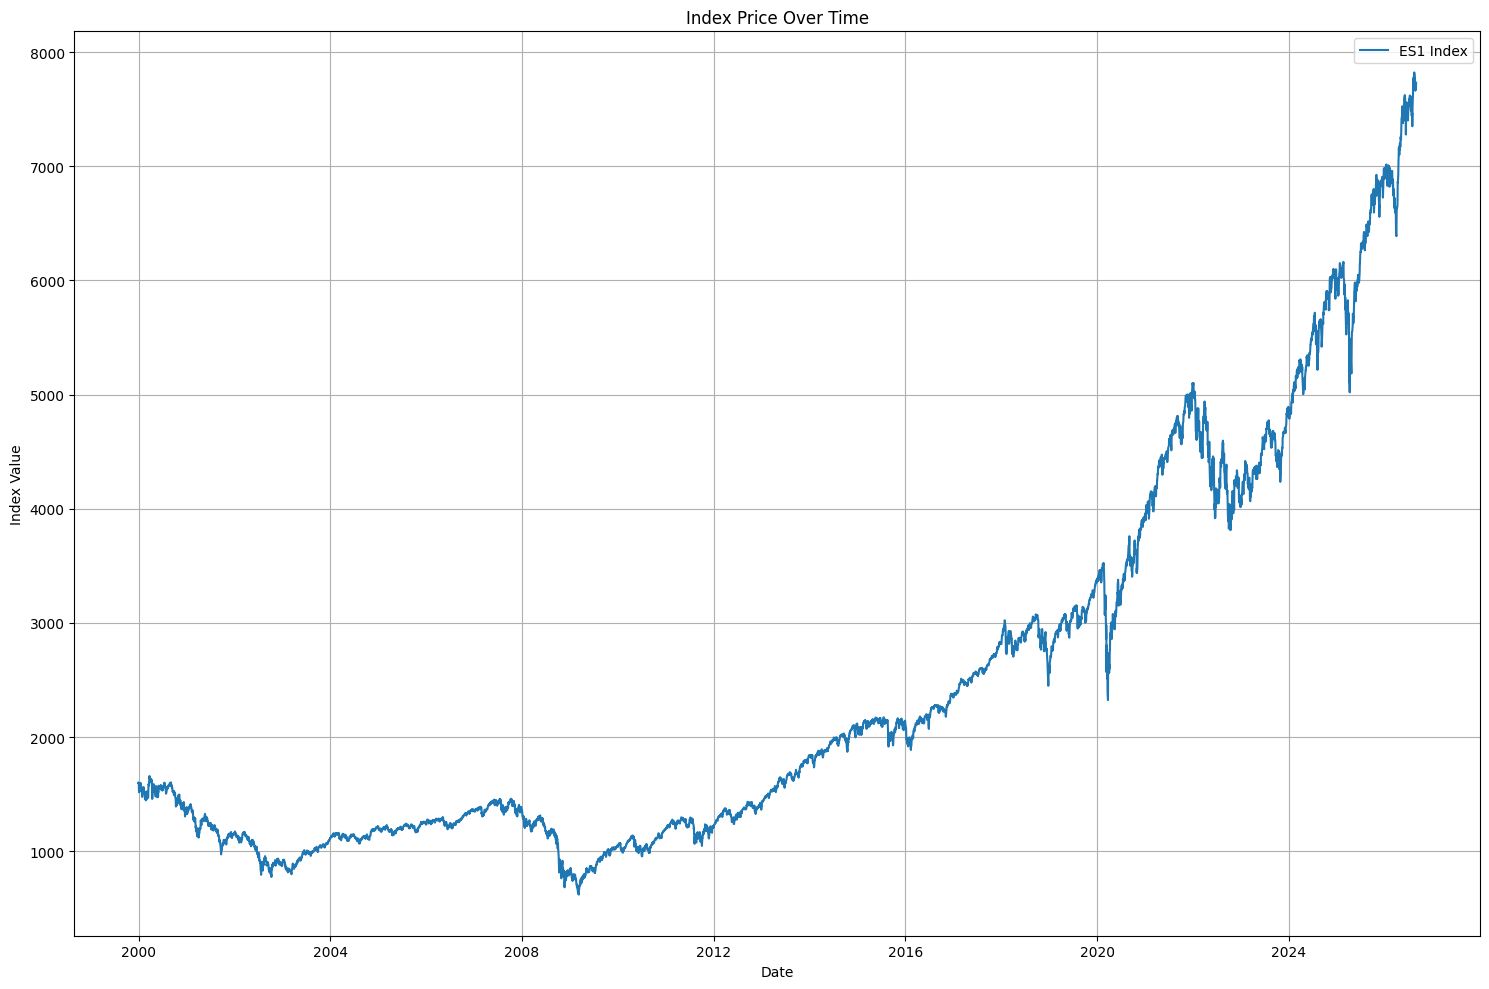

In [135]:
from pathlib import Path
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'Data_V1 copy.xlsx').exists())
file_path = str(_root / 'data' / 'Data_V1 copy.xlsx')
sheet_name = 'Series'
top_n_columns = 1
data, returns = functions.process_data(file_path, sheet_name, top_n_columns)

plt.figure(figsize=(15,10))
for column in data.columns[0:]:
    plt.plot(data.index, data[column], label=column)
plt.title('Index Price Over Time')
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

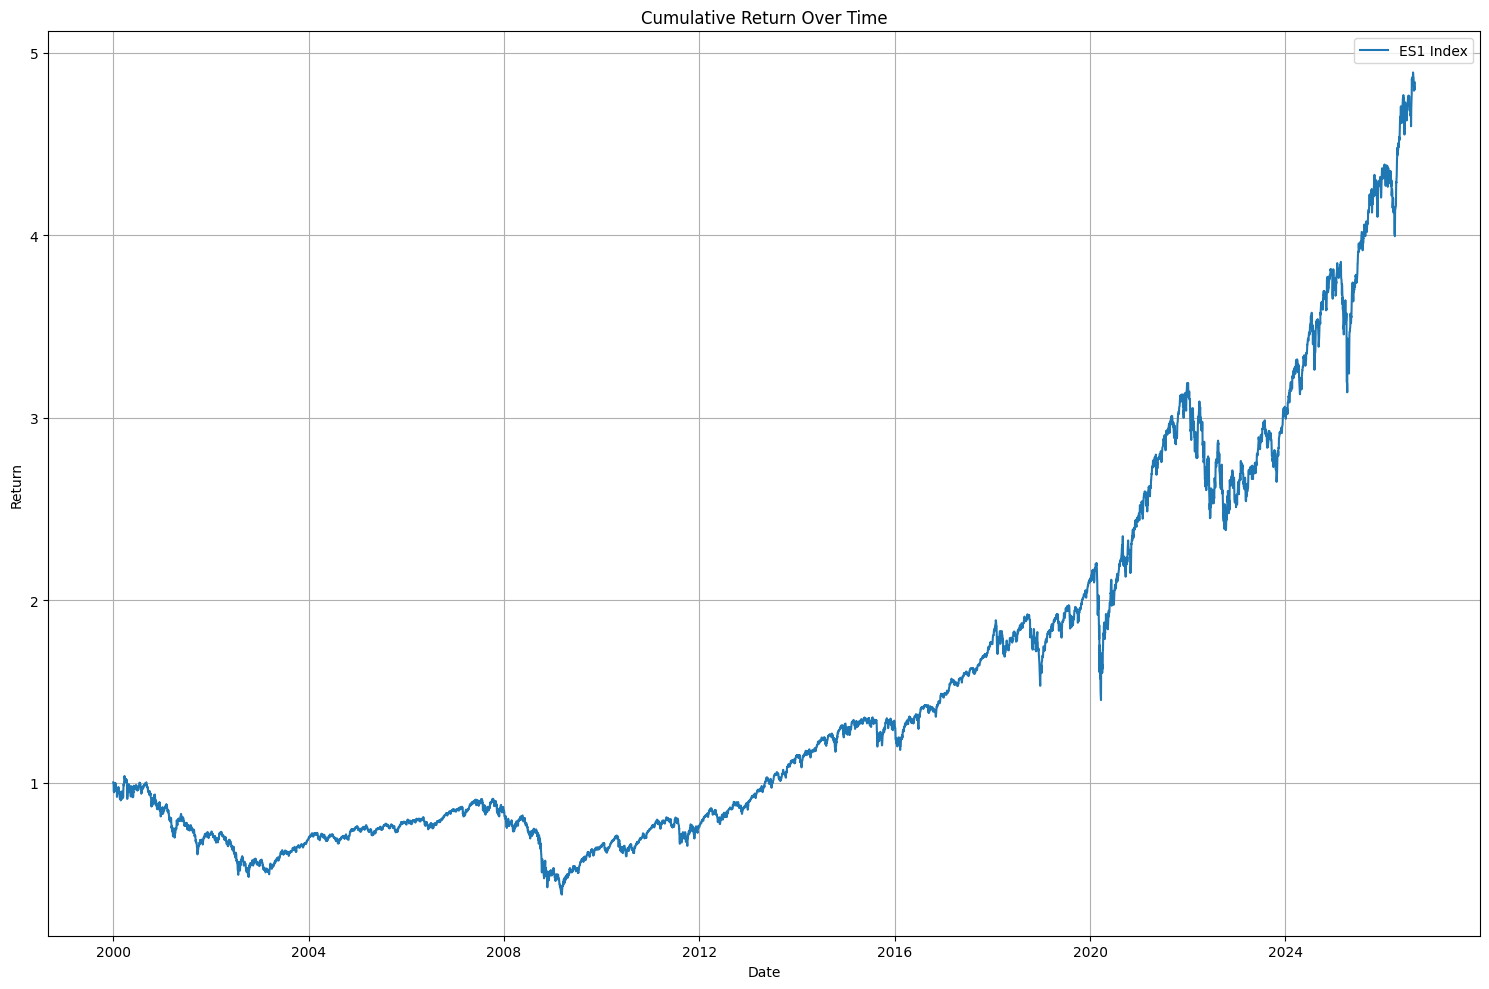

In [136]:

returns = returns.dropna()
returns.mean(), returns.std()

plt.figure(figsize=(15,10))
for column in returns.columns[0:]:
    plt.plot(returns.index, (returns[column] + 1).cumprod(), label=column)
plt.xlabel('Date')
plt.ylabel('Return')
plt.title('Cumulative Return Over Time')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

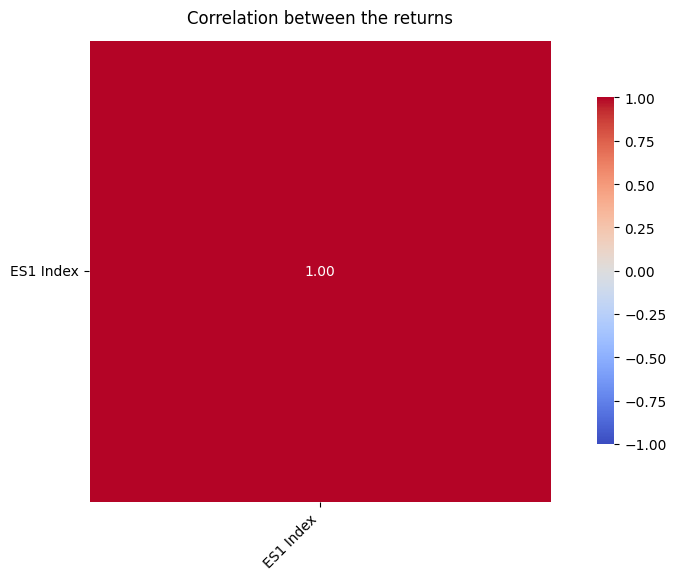

In [137]:
# Calculate the matrix for the returns 
corr_matrix = returns.corr()
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig,ax = plt.subplots(figsize=(12,6))
cmap = sns.diverging_palette(250,10, as_cmap=True)
sns.heatmap(corr_matrix, cmap = "coolwarm", vmin=-1, vmax=1, center=0, annot=True, 
            square= True, linewidths=0.5, fmt='.2f', annot_kws={"size":10},
            cbar_kws={"shrink":.75})
ax.set_xticklabels(ax.get_xticklabels(), rotation= 45, horizontalalignment= 'right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.title("Correlation between the returns", fontsize = 12, pad=12)
plt.show()


## Visualizing the SGN Trend Signal (Moskowitz et al. 2012)

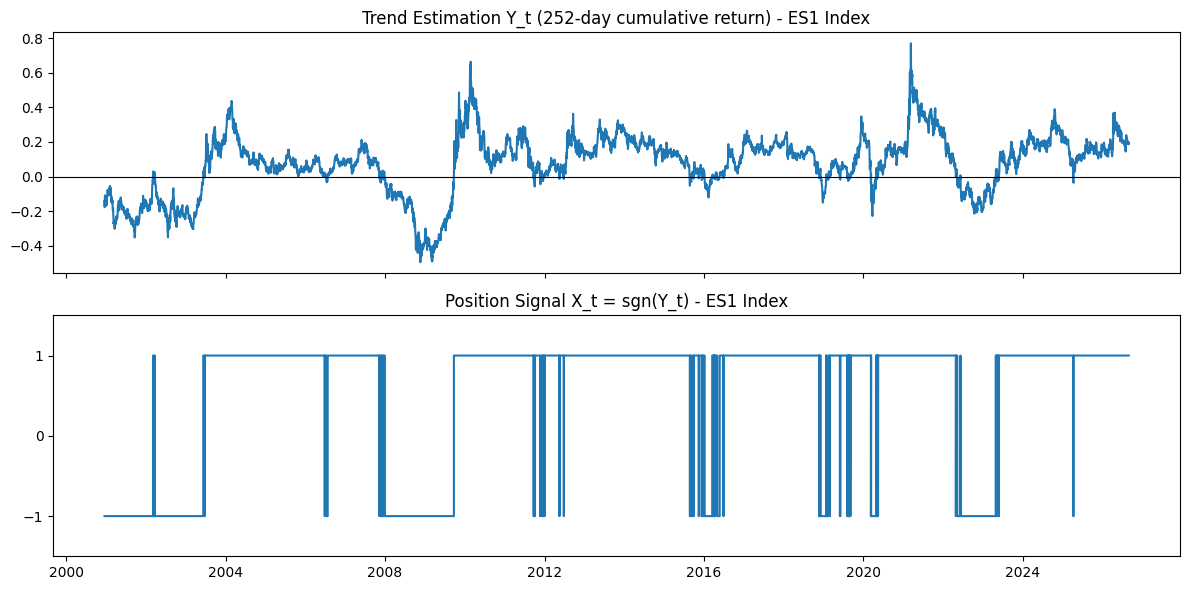

In [138]:
import matplotlib.pyplot as plt

# Trend estimation: Y_t = r_{t-252,t} (252-day cumulative return)
Y_t = (1 + returns).rolling(window=252).apply(np.prod, raw=True) - 1
Y_t = Y_t.dropna()

# Position sizing: X_t = sgn(Y_t)
sgn_signal = np.sign(Y_t)

# Pick one asset to inspect, e.g. the first column
asset = returns.columns[0]


fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(Y_t.index, Y_t[asset])
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title(f'Trend Estimation Y_t (252-day cumulative return) - {asset}')

axes[1].step(sgn_signal.index, sgn_signal[asset], where='post')
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_yticks([-1, 0, 1])
axes[1].set_title(f'Position Signal X_t = sgn(Y_t) - {asset}')

plt.tight_layout()
plt.show()



## Long only 

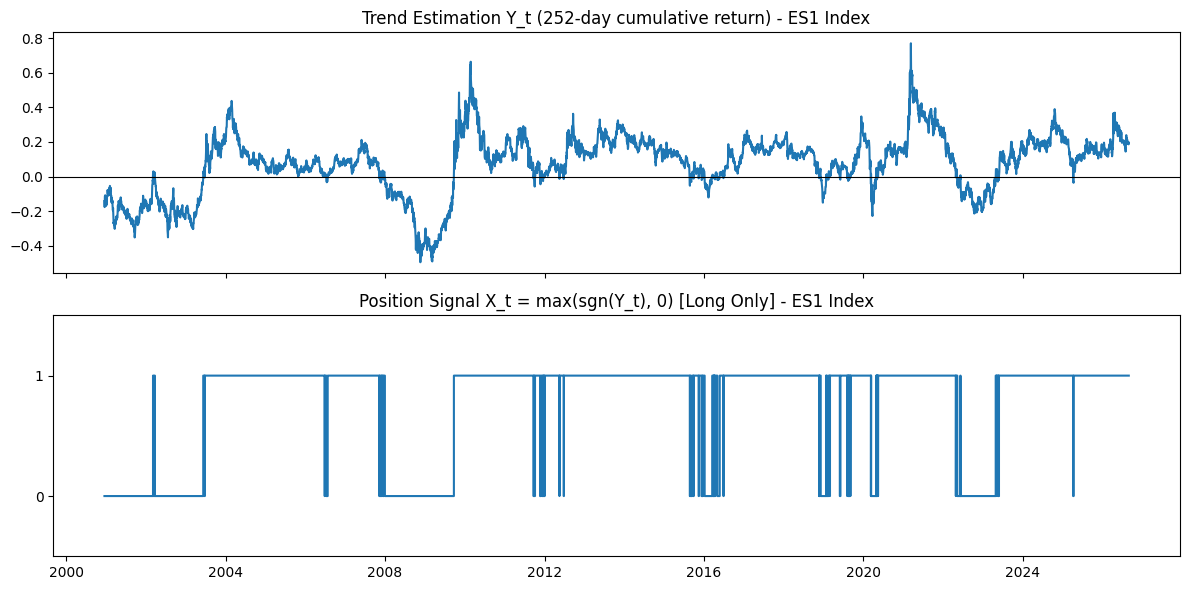

In [139]:

import matplotlib.pyplot as plt

# Trend estimation: Y_t = r_{t-252,t} (252-day cumulative return)
Y_t = (1 + returns).rolling(window=252).apply(np.prod, raw=True) - 1
Y_t = Y_t.dropna()

# Position sizing: X_t = max(sgn(Y_t), 0)  (long-only: negative signals clipped to 0)
long_signal = np.sign(Y_t).map(lambda x: x if x > 0 else 0)

asset = returns.columns[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(Y_t.index, Y_t[asset])
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title(f'Trend Estimation Y_t (252-day cumulative return) - {asset}')

axes[1].step(long_signal.index, long_signal[asset], where='post')
axes[1].set_ylim(-0.5, 1.5)
axes[1].set_yticks([0, 1])
axes[1].set_title(f'Position Signal X_t = max(sgn(Y_t), 0) [Long Only] - {asset}')

plt.tight_layout()
plt.show()

## Visualizing the MACD (Baz et al. 2015) Trend Signal

Per the paper, for each short/long half-life pair (S,L):

- MACD_t = EWMA(p, halflife=S) - EWMA(p, halflife=L)
- q_t = MACD_t / std_63(p)            (normalize by 63-day rolling std of prices)
- y_t = q_t / std_252(q)              (normalize by its own 252-day rolling std) -> this is the trend signal, analogous to Y_t
- X_t = y_t * exp(-y_t^2/4) / 0.89    (position sizing, bounded roughly in [-1,1])

The final signal used in TSMOM_daily averages X_t across three (S,L) pairs: (8,24), (16,48), (32,96).


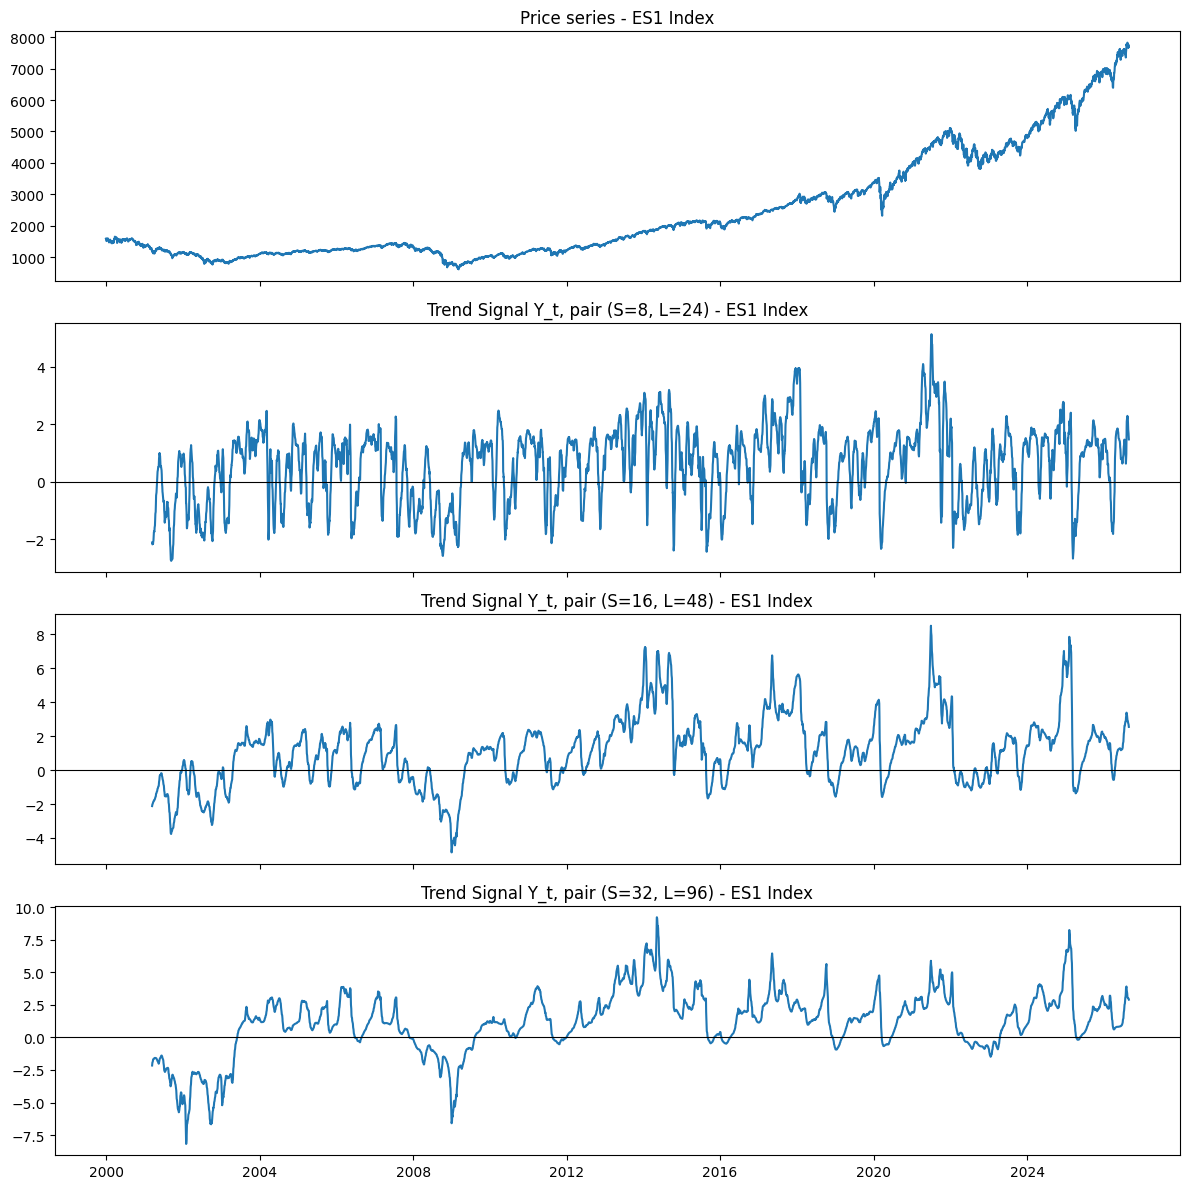

In [140]:
# Pick one asset to inspect
asset = data.columns[0]
prices = data[[asset]]

span_pairs = [(8, 24), (16, 48), (32, 96)]

fig, axes = plt.subplots(len(span_pairs) + 1, 1, figsize=(12, 12), sharex=True)

axes[0].plot(prices.index, prices[asset])
axes[0].set_title(f'Price series - {asset}')

for i, (short_span, long_span) in enumerate(span_pairs, start=1):
    lambda_short = (short_span - 1) / float(short_span)
    lambda_long = (long_span - 1) / float(long_span)
    hl_short = np.log(0.5) / np.log(lambda_short)
    hl_long = np.log(0.5) / np.log(lambda_long)

    ewma_short = prices.ewm(halflife=hl_short, ignore_na=True).mean()
    ewma_long = prices.ewm(halflife=hl_long, ignore_na=True).mean()
    macd = ewma_short - ewma_long
    rolling_std_63 = prices.rolling(window=63).std()
    q = macd / rolling_std_63
    y_t = (q / q.rolling(window=252).std()).dropna()   # trend signal Y_t for this (S,L) pair

    axes[i].plot(y_t.index, y_t[asset])
    axes[i].axhline(0, color='black', lw=0.8)
    axes[i].set_title(f'Trend Signal Y_t, pair (S={short_span}, L={long_span}) - {asset}')

plt.tight_layout()
plt.show()



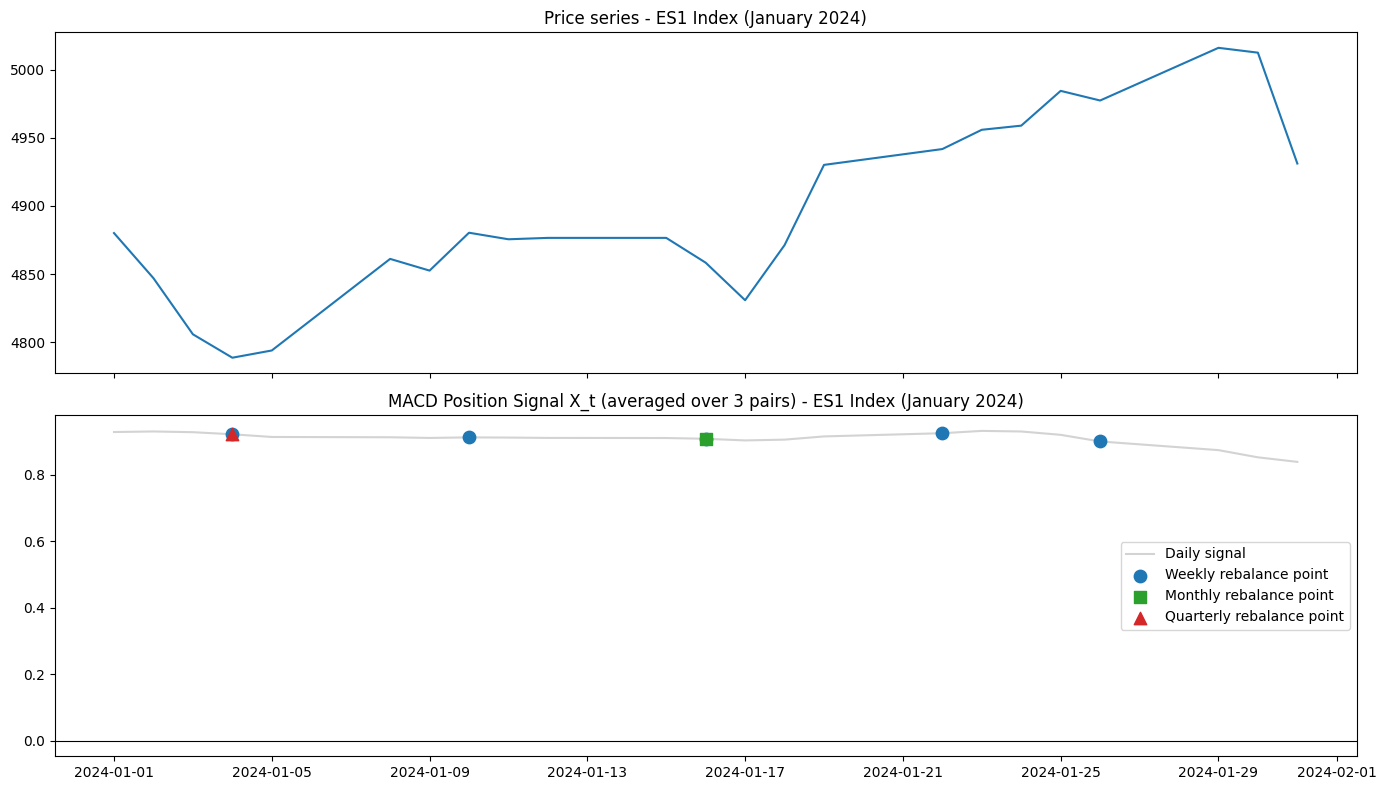

In [141]:
# Final MACD position signal X_t used in TSMOM_daily: average of the 3 pairs
macd_position_signal = functions.calculate_cta_momentum_signal(data)

# Limit the view to January 2024
start_date = '2024-01-01'
end_date = '2024-01-31'
data_period = data.loc[start_date:end_date]
macd_position_signal_period = macd_position_signal.loc[start_date:end_date]

# Rebalance signal points sampled from the FULL signal series (same convention as TSMOM_rebalance),
# then filtered down to the January 2024 window for display
freqs = {'Weekly': 4, 'Monthly': 20, 'Quarterly': 62}
rebalance_points = {}
for label, freq in freqs.items():
    sampled = macd_position_signal.iloc[::freq]
    rebalance_points[label] = sampled.loc[sampled.index.intersection(macd_position_signal_period.index)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(data_period.index, data_period[asset])
axes[0].set_title(f'Price series - {asset} (January 2024)')

# Daily signal as the base line
axes[1].plot(macd_position_signal_period.index, macd_position_signal_period[asset],
             color='lightgray', label='Daily signal', zorder=1)

# Overlay the rebalance-sampled points for each frequency
markers = {'Weekly': ('o', 'tab:blue'), 'Monthly': ('s', 'tab:green'), 'Quarterly': ('^', 'tab:red')}
for label, points in rebalance_points.items():
    marker, color = markers[label]
    axes[1].scatter(points.index, points[asset], label=f'{label} rebalance point',
                     marker=marker, color=color, s=80, zorder=3)

axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title(f'MACD Position Signal X_t (averaged over 3 pairs) - {asset} (January 2024)')
axes[1].legend()

plt.tight_layout()
plt.show()


## MACD with long only 

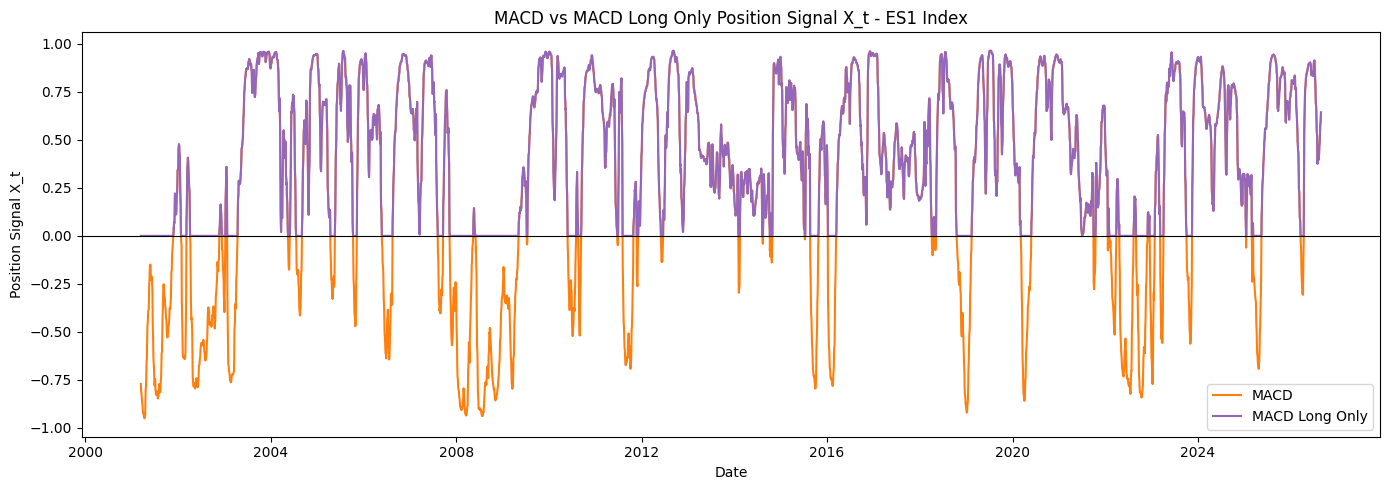

In [142]:
# MACD Long Only: same phi(Y_t) signal as MACD, but negative values clipped to 0 (no short positions)
asset = returns.columns[0]

macd_signal = functions.calculate_cta_momentum_signal(data)
macd_long_only_signal = functions.calculate_cta_momentum_signal_long_only(data)

common_index = macd_signal.index.intersection(macd_long_only_signal.index)

plt.figure(figsize=(14, 5))
plt.plot(common_index, macd_signal.loc[common_index, asset], label='MACD', color='tab:orange')
plt.plot(common_index, macd_long_only_signal.loc[common_index, asset], label='MACD Long Only', color='tab:purple')
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('Date')
plt.ylabel('Position Signal X_t')
plt.title(f'MACD vs MACD Long Only Position Signal X_t - {asset}')
plt.legend()
plt.tight_layout()
plt.show()


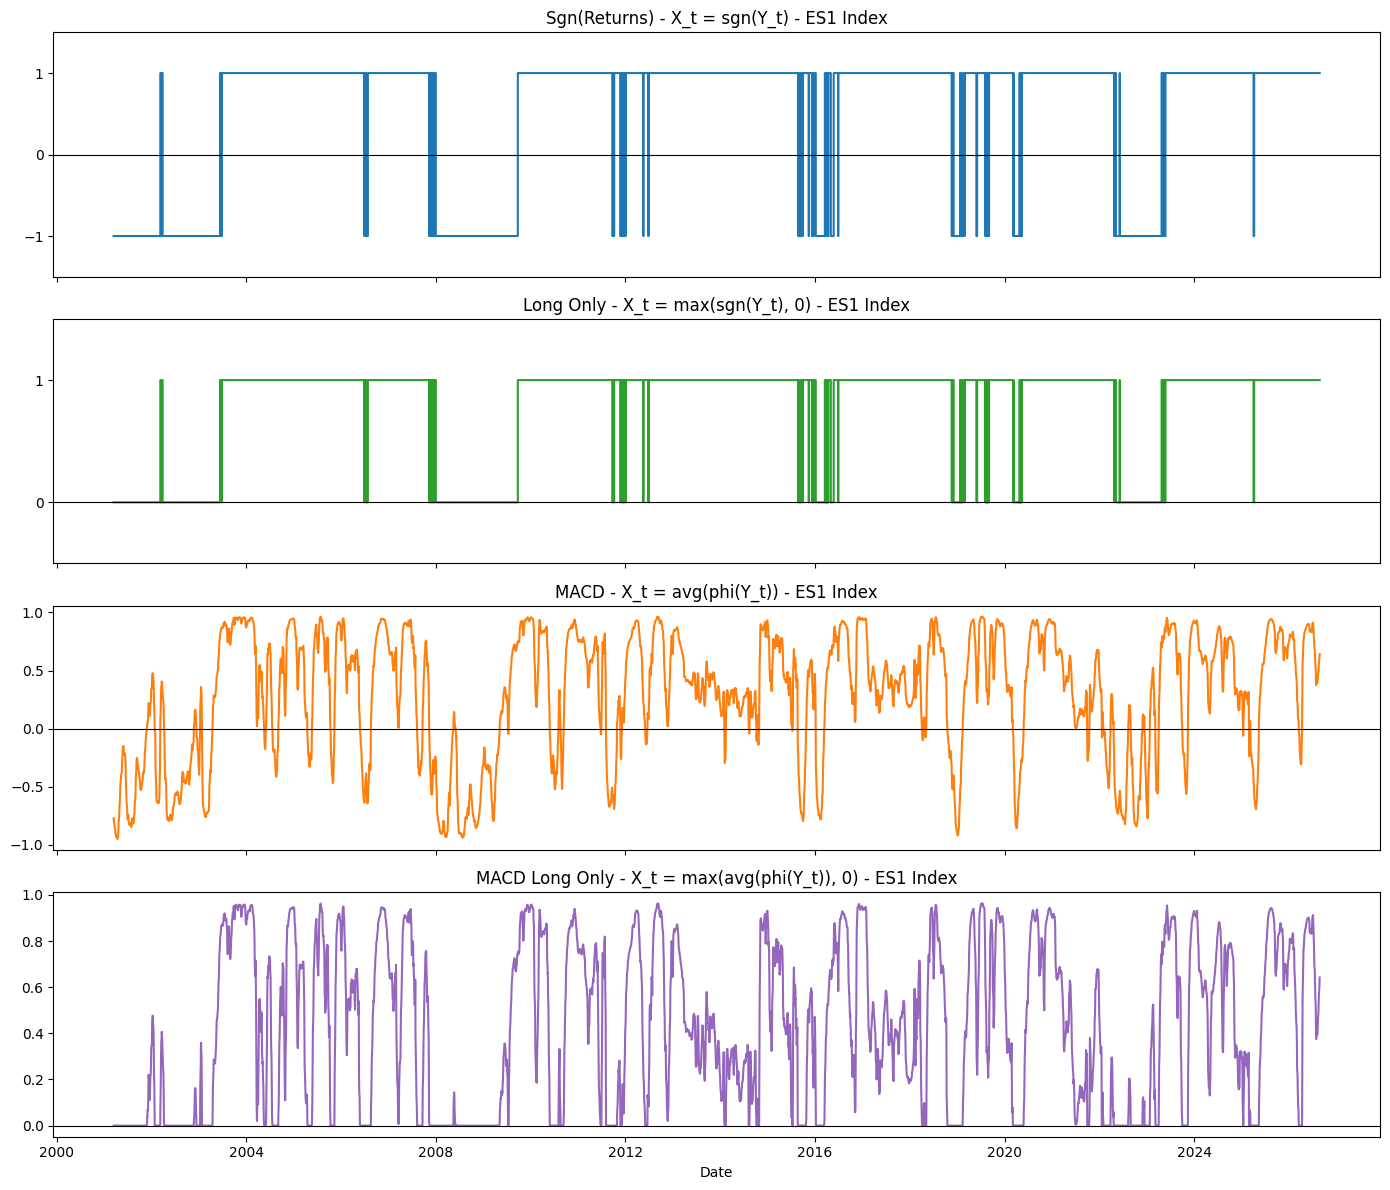

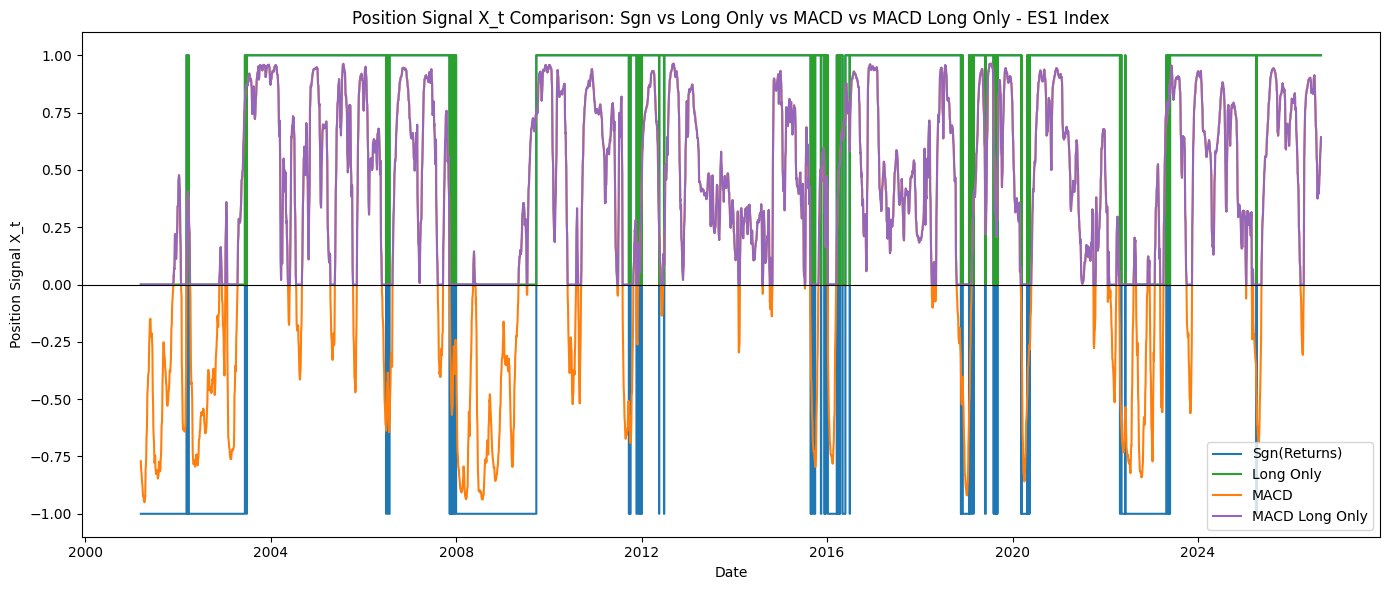

In [143]:
# Compare the position signal X_t across the four strategies: Sgn(Returns), Long Only, MACD, MACD Long Only

asset = returns.columns[0]

# Sgn(Returns) - Moskowitz et al. 2012: X_t = sgn(Y_t)
Y_t_cum = (1 + returns).rolling(window=252).apply(np.prod, raw=True) - 1
Y_t_cum = Y_t_cum.dropna()
sgn_signal = np.sign(Y_t_cum)

# Long Only: X_t = max(sgn(Y_t), 0)
long_signal = sgn_signal.map(lambda x: x if x > 0 else 0)

# MACD (Baz et al. 2015): X_t = average of phi(Y_t) over 3 (S,L) pairs
macd_position_signal = functions.calculate_cta_momentum_signal(data)

# MACD Long Only: same phi(Y_t) signal, negative values clipped to 0
macd_long_only_signal = functions.calculate_cta_momentum_signal_long_only(data)

# Align all four signals on their common date range
common_index = sgn_signal.index.intersection(long_signal.index).intersection(macd_position_signal.index).intersection(macd_long_only_signal.index)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].step(common_index, sgn_signal.loc[common_index, asset], where='post', color='tab:blue')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_yticks([-1, 0, 1])
axes[0].set_title(f'Sgn(Returns) - X_t = sgn(Y_t) - {asset}')

axes[1].step(common_index, long_signal.loc[common_index, asset], where='post', color='tab:green')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylim(-0.5, 1.5)
axes[1].set_yticks([0, 1])
axes[1].set_title(f'Long Only - X_t = max(sgn(Y_t), 0) - {asset}')

axes[2].plot(common_index, macd_position_signal.loc[common_index, asset], color='tab:orange')
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title(f'MACD - X_t = avg(phi(Y_t)) - {asset}')

axes[3].plot(common_index, macd_long_only_signal.loc[common_index, asset], color='tab:purple')
axes[3].axhline(0, color='black', lw=0.8)
axes[3].set_title(f'MACD Long Only - X_t = max(avg(phi(Y_t)), 0) - {asset}')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Combined comparison: all four signals as different colored lines on one plot
plt.figure(figsize=(14, 6))
plt.step(common_index, sgn_signal.loc[common_index, asset], where='post', label='Sgn(Returns)', color='tab:blue')
plt.step(common_index, long_signal.loc[common_index, asset], where='post', label='Long Only', color='tab:green')
plt.plot(common_index, macd_position_signal.loc[common_index, asset], label='MACD', color='tab:orange')
plt.plot(common_index, macd_long_only_signal.loc[common_index, asset], label='MACD Long Only', color='tab:purple')
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('Date')
plt.ylabel('Position Signal X_t')
plt.title(f'Position Signal X_t Comparison: Sgn vs Long Only vs MACD vs MACD Long Only - {asset}')
plt.legend()
plt.tight_layout()
plt.show()


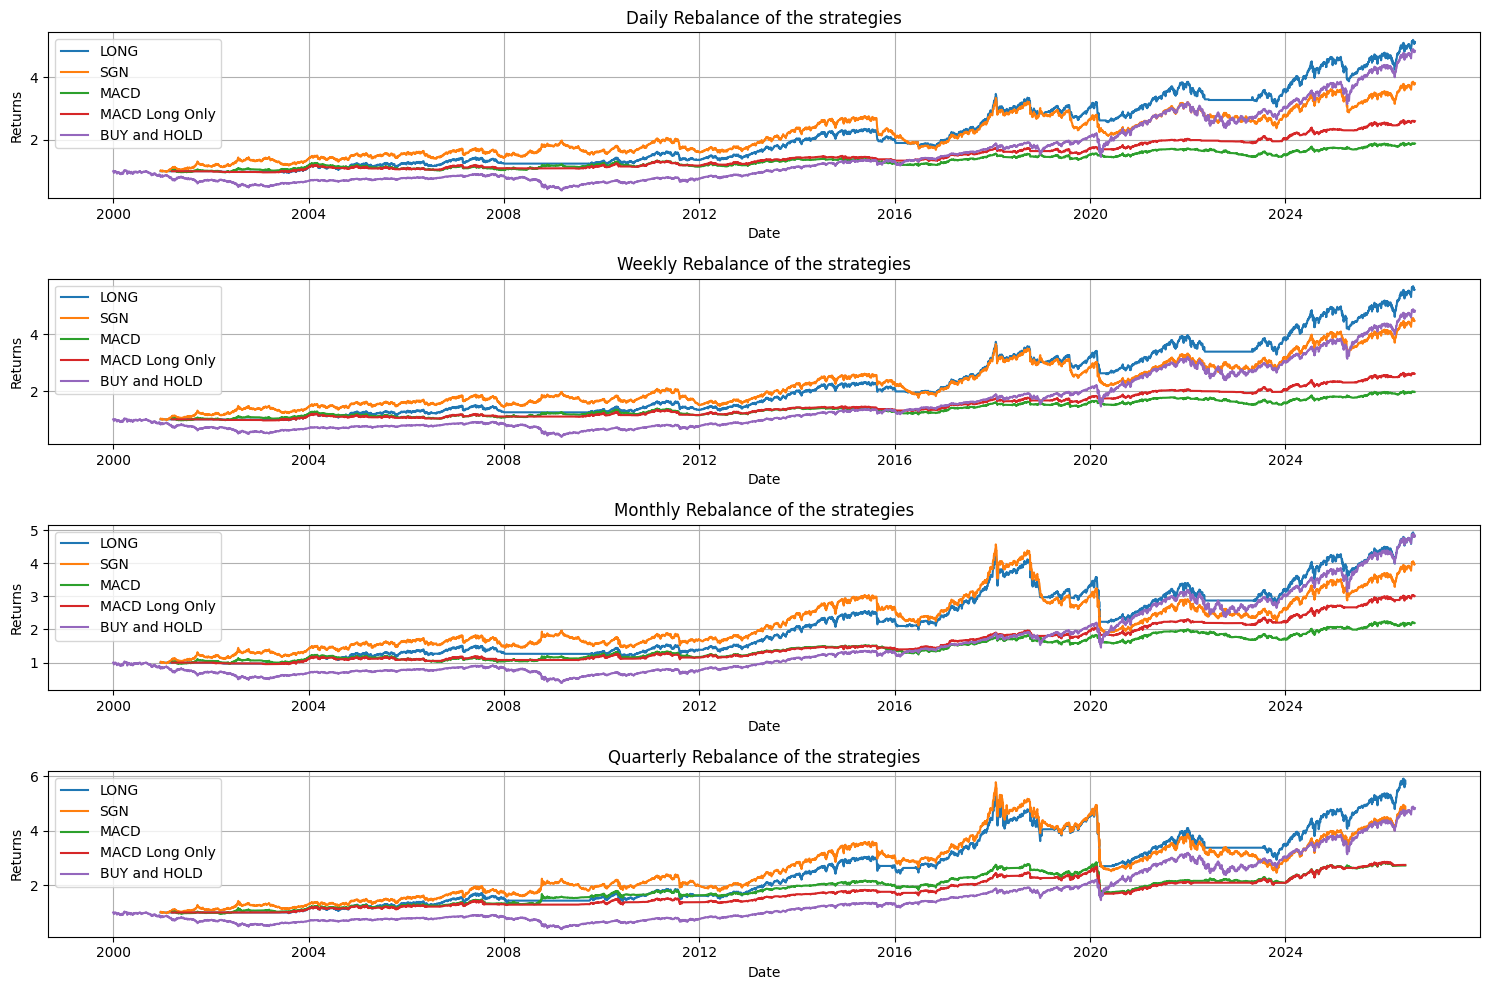

In [144]:
# Plot 5 different strategies (Long, SGN, MACD, MACD Long Only, Buy+Hold) for daily, weekly, monthly and quarterly rebalance
plt.figure(figsize=(15,10))

# Buy and hold does not depend on rebalance frequency - it's just the equal-weighted average of raw asset returns
buy_and_hold = (returns.mean(axis=1)+1).cumprod()

plt.subplot(4,1,1)
# Sum of the returns 
r_Long = (functions.TSMOM_daily(returns, data, trading_str = 'LONG')+1).cumprod()
r_SGN = (functions.TSMOM_daily(returns, data, trading_str = 'SGN')+1).cumprod()
r_MACD = (functions.TSMOM_daily(returns, data, trading_str = 'MACD')+1).cumprod()
r_MACD_LONG = (functions.TSMOM_daily(returns, data, trading_str = 'MACD_LONG')+1).cumprod()
plt.plot(r_Long, label = 'LONG')
plt.plot(r_SGN, label = 'SGN')
plt.plot(r_MACD, label = 'MACD')
plt.plot(r_MACD_LONG, label = 'MACD Long Only')
plt.plot(buy_and_hold, label = 'BUY and HOLD')
plt.xlabel("Date")
plt.ylabel("Returns")
plt.title("Daily Rebalance of the strategies")
plt.legend()
plt.grid()


plt.subplot(4,1,2)
r_Long = (functions.TSMOM_rebalance(returns, data, trading_str = 'LONG', freq_balance=4) + 1 ).cumprod()
r_SGN = (functions.TSMOM_rebalance(returns, data, trading_str = 'SGN', freq_balance=4) + 1 ).cumprod()
r_MACD = (functions.TSMOM_rebalance(returns, data, trading_str = 'MACD', freq_balance=4) + 1 ).cumprod()
r_MACD_LONG = (functions.TSMOM_rebalance(returns, data, trading_str = 'MACD_LONG', freq_balance=4) + 1 ).cumprod()

plt.plot(r_Long, label = 'LONG')
plt.plot(r_SGN, label = 'SGN')
plt.plot(r_MACD, label = 'MACD')
plt.plot(r_MACD_LONG, label = 'MACD Long Only')
plt.plot(buy_and_hold, label = 'BUY and HOLD')
plt.xlabel("Date")
plt.ylabel("Returns")
plt.title("Weekly Rebalance of the strategies")
plt.legend()
plt.grid()


plt.subplot(4,1,3)
r_Long = (functions.TSMOM_rebalance(returns, data, trading_str = 'LONG', freq_balance=20) + 1 ).cumprod()
r_SGN = (functions.TSMOM_rebalance(returns, data, trading_str = 'SGN', freq_balance=20) + 1 ).cumprod()
r_MACD = (functions.TSMOM_rebalance(returns, data, trading_str = 'MACD', freq_balance=20) + 1 ).cumprod()
r_MACD_LONG = (functions.TSMOM_rebalance(returns, data, trading_str = 'MACD_LONG', freq_balance=20) + 1 ).cumprod()

plt.plot(r_Long, label = 'LONG')
plt.plot(r_SGN, label = 'SGN')
plt.plot(r_MACD, label = 'MACD')
plt.plot(r_MACD_LONG, label = 'MACD Long Only')
plt.plot(buy_and_hold, label = 'BUY and HOLD')
plt.xlabel("Date")
plt.ylabel("Returns")
plt.title("Monthly Rebalance of the strategies")
plt.legend()
plt.grid()


plt.subplot(4,1,4)
r_Long = (functions.TSMOM_rebalance(returns, data, trading_str = 'LONG', freq_balance=62) + 1 ).cumprod()
r_SGN = (functions.TSMOM_rebalance(returns, data, trading_str = 'SGN', freq_balance=62) + 1 ).cumprod()
r_MACD = (functions.TSMOM_rebalance(returns, data, trading_str = 'MACD', freq_balance=62) + 1 ).cumprod()
r_MACD_LONG = (functions.TSMOM_rebalance(returns, data, trading_str = 'MACD_LONG', freq_balance=62) + 1 ).cumprod()

plt.plot(r_Long, label = 'LONG')
plt.plot(r_SGN, label = 'SGN')
plt.plot(r_MACD, label = 'MACD')
plt.plot(r_MACD_LONG, label = 'MACD Long Only')
plt.plot(buy_and_hold, label = 'BUY and HOLD')
plt.xlabel("Date")
plt.ylabel("Returns")
plt.title("Quarterly Rebalance of the strategies")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


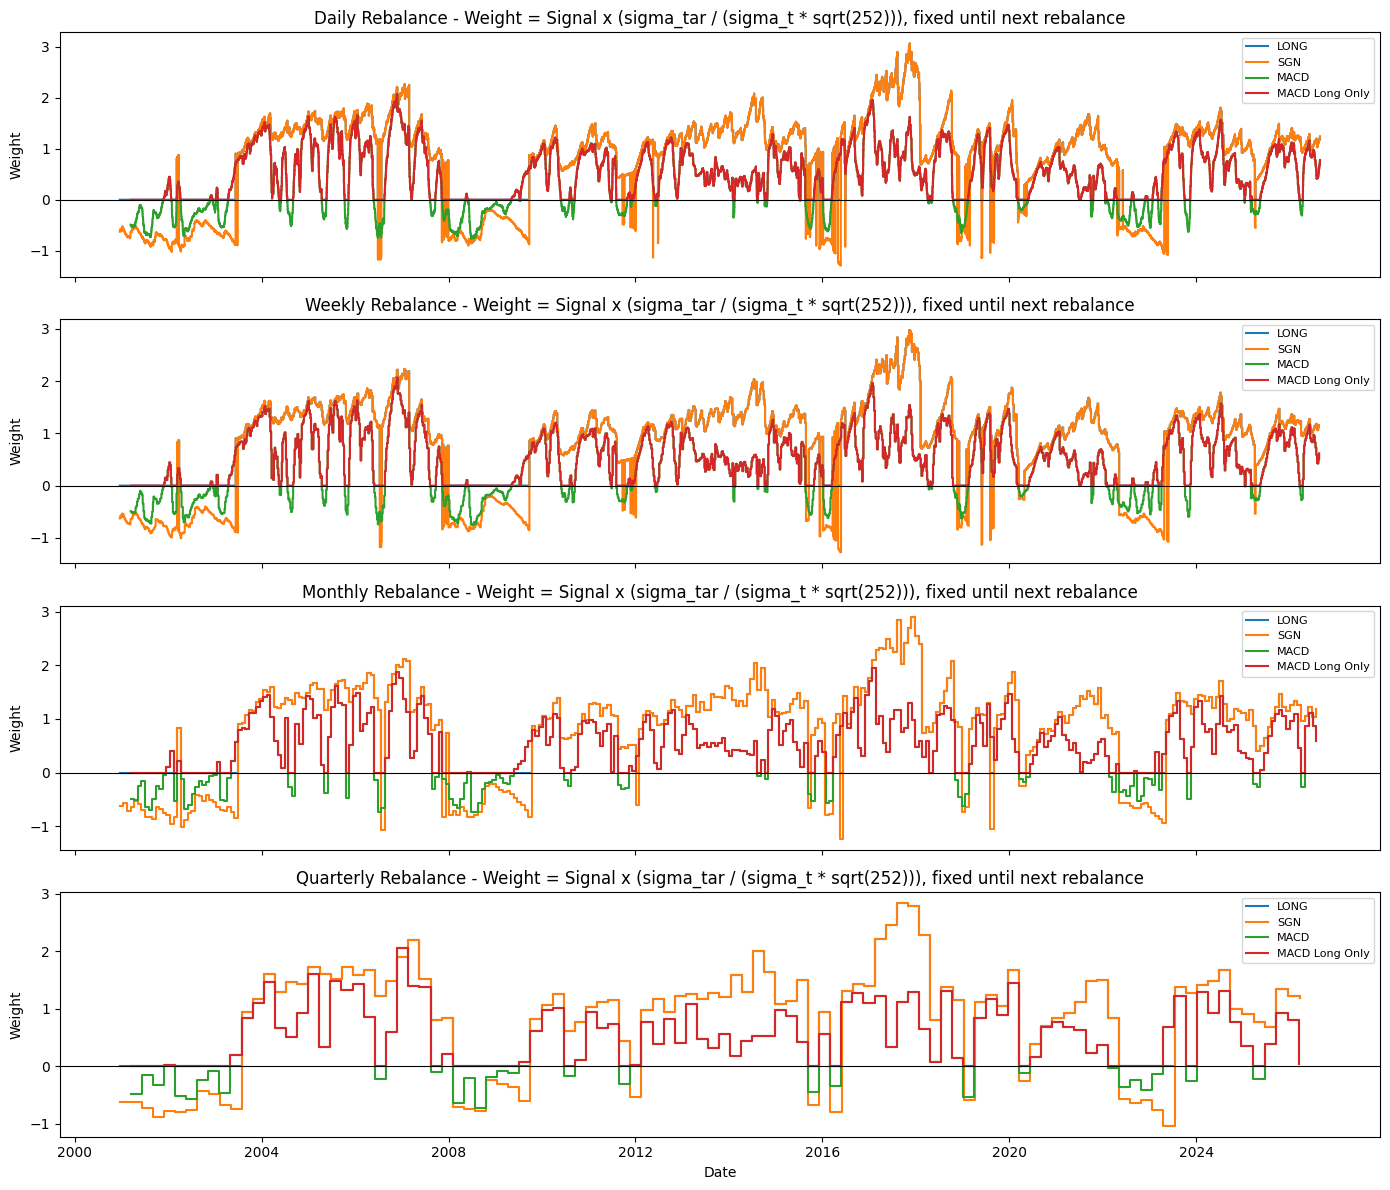

,LONG,SGN,MACD,MACD Long Only
Date,,,,
2000-12-18,0.000000,-0.627355,NaN,NaN
2001-03-13,NaN,NaN,-0.488581,0.000000
2001-03-14,0.000000,-0.625301,NaN,NaN
2001-06-07,NaN,NaN,-0.153463,0.000000
2001-06-08,0.000000,-0.731637,NaN,NaN
...,...,...,...,...
2025-09-19,1.347108,1.347108,NaN,NaN
2025-12-16,NaN,NaN,0.802636,0.802636
2025-12-17,1.229135,1.229135,NaN,NaN


In [145]:
# Visualize AND build a DataFrame of the position weight (signal * vol-scale) that TSMOM_rebalance
# holds fixed between rebalance dates, for daily/weekly/monthly/quarterly frequencies.

asset = returns.columns[0]
freqs = {'Daily': 1, 'Weekly': 4, 'Monthly': 20, 'Quarterly': 62}
weight_tables = {}

fig, axes = plt.subplots(len(freqs), 1, figsize=(14, 12), sharex=True)

for ax, (freq_name, freq) in zip(axes, freqs.items()):
    w_long = functions.weight_series(returns, data, 'LONG', freq)
    w_sgn = functions.weight_series(returns, data, 'SGN', freq)
    w_macd = functions.weight_series(returns, data, 'MACD', freq)
    w_macd_long = functions.weight_series(returns, data, 'MACD_LONG', freq)

    weight_df = pd.concat([w_long, w_sgn, w_macd, w_macd_long], axis=1)
    weight_df.columns = ['LONG', 'SGN', 'MACD', 'MACD Long Only']
    weight_df.index.name = 'Date'
    weight_tables[freq_name] = weight_df

    ax.step(w_long.index, w_long.values, where='post', label='LONG')
    ax.step(w_sgn.index, w_sgn.values, where='post', label='SGN')
    ax.step(w_macd.index, w_macd.values, where='post', label='MACD')
    ax.step(w_macd_long.index, w_macd_long.values, where='post', label='MACD Long Only')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{freq_name} Rebalance - Weight = Signal x (sigma_tar / (sigma_t * sqrt(252))), fixed until next rebalance')
    ax.set_ylabel('Weight')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

weight_tables['Quarterly']



In [146]:
# Sum of the returns 

r_long = functions.TSMOM_daily(returns, data, trading_str = 'LONG')
r_SGN = functions.TSMOM_daily(returns, data, trading_str = 'SGN')
r_MACD = functions.TSMOM_daily(returns, data, trading_str = 'MACD') 
buy_and_hold = returns.mean(axis=1)
tmp = pd.concat([r_long, r_SGN, r_MACD, buy_and_hold], axis=1).dropna()
col_names = ['Long Only', "Long+Short", "MACD", "Buy+Hold"]
tmp.columns = col_names
functions.StatV1(tmp, freq=252)

2001-03-14
2026-08-27


,Mean,Std,Sharpe,Skew,Kurt,MaxDD,DownsideDev,Sortino,PerPosReturn
Long Only,6.411479,13.574325,0.472324,-1.046891,7.558287,26.038108,1.112579,0.404371,40.712776
Long+Short,4.889902,15.515475,0.315163,-0.748216,4.251217,38.91006,1.083515,0.347902,51.585624
MACD,2.433381,9.107295,0.267190,-0.799920,5.899147,19.296781,0.630869,0.281614,50.860767
Buy+Hold,7.277840,18.722131,0.388729,0.060073,13.573397,57.540675,1.262153,0.438159,52.401087


## Features for the neural layers

In [147]:
# Normalized_returns need to discussed 
norm_return_weekly = functions.normalized_lag_returns(returns, period =5)
norm_return_monthly = functions.normalized_lag_returns(returns, period =21)
norm_return_quarterly = functions.normalized_lag_returns(returns, period = 63)
norm_return_half_year = functions.normalized_lag_returns(returns, period=126)
norm_return_year = functions.normalized_lag_returns(returns, period =252)

# MAC
macd_8_24 = functions.EMA_ind(8,24, data)
macd_16_48 = functions.EMA_ind(16,48, data)
macd_32_96 = functions.EMA_ind(32,96, data)

# Building the features 
features = pd.concat([
    norm_return_weekly, norm_return_monthly,
    norm_return_quarterly, norm_return_half_year, 
    norm_return_year, macd_8_24, macd_16_48, macd_32_96
], axis =1).dropna()
features.shape, returns.shape 

# %%
scaler = StandardScaler()


# sperate data into Training, Validation and Testing
target_returns_or, target_sigma_or = functions.target_value(returns, features)
features_or  = functions.train_value(returns, features)

# target_returns = scaler.fit_transform(target_returns_or)
# target_sigma = scaler.fit_transform(target_sigma_or)
# features = scaler.fit_transform(features_or)

X = features_or.values
y_return = target_returns_or.values 
y_sigma = target_sigma_or.values 


train_size = int(len(X)*0.7)
val_size = int(len(X)*0.2)
test_size = len(X) -train_size-val_size 
X_train, X_val, X_test = X[:train_size], X[train_size: train_size+val_size], X[train_size+val_size:]
y_train_returns, y_val_returns, y_test_returns = y_return[:train_size], y_return[train_size: train_size+val_size], y_return[train_size+val_size:]
y_train_sigma, y_val_sigma, y_test_sigma = y_sigma[:train_size], y_sigma[train_size: train_size+val_size], y_sigma[train_size+val_size:]

# Standardize the features - fit the scaler on the training set only, then apply
# the same fitted scaler to validation/test (avoids fitting on val/test statistics)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
# y_train_returns = scaler.fit_transform(y_train_returns)
# y_val_returns = scaler.fit_transform(y_val_returns)
# y_test_returns = scaler.fit_transform(y_test_returns)
# y_train_sigma = scaler.fit_transform(y_train_sigma)
# y_val_sigma = scaler.fit_transform(y_val_sigma)
# y_test_sigma = scaler.fit_transform(y_test_sigma)

# Change to tensorflow format
X_train_tf = tf.convert_to_tensor(X_train, dtype=tf.float32) # (1322,35)
X_val_tf = tf.convert_to_tensor(X_val, dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_train_returns_tf = tf.convert_to_tensor(y_train_returns, dtype=tf.float32)
y_val_returns_tf = tf.convert_to_tensor(y_val_returns, dtype=tf.float32)
y_test_returns_tf = tf.convert_to_tensor(y_test_returns, dtype=tf.float32)
y_train_sigma_tf = tf.convert_to_tensor(y_train_sigma, dtype=tf.float32)
y_val_sigma_tf = tf.convert_to_tensor(y_val_sigma, dtype=tf.float32)
y_test_sigma_tf = tf.convert_to_tensor(y_test_sigma, dtype=tf.float32)
X_train.shape, y_train_returns.shape, y_train_sigma.shape, X_test_tf.shape 
target_returns_or, target_sigma_or 

(            ES1 Index
 Date                 
 2001-03-14  -0.023388
 2001-03-15   0.003422
 2001-03-16  -0.019411
 2001-03-19   0.016138
 2001-03-20  -0.023717
 ...               ...
 2026-08-21   0.003752
 2026-08-24  -0.002795
 2026-08-25   0.002901
 2026-08-26  -0.000260
 2026-08-27   0.005592
 
 [6622 rows x 1 columns],
             ES1 Index
 Date                 
 2001-03-13   0.014901
 2001-03-14   0.015111
 2001-03-15   0.014914
 2001-03-16   0.014950
 2001-03-19   0.015134
 ...               ...
 2026-08-20   0.008086
 2026-08-21   0.007973
 2026-08-24   0.007866
 2026-08-25   0.007747
 2026-08-26   0.007621
 
 [6622 rows x 1 columns])

In [148]:
# %%
# seq_length = 63, 126, 252 to see which one better fit LSTM MODEL 
seq_length = 252 # 1 Year trading 
X_train_seq, y_train_seq= functions.create_sequences(X_train,  y_train_returns, y_train_sigma, seq_length)
X_val_seq, y_val_seq  = functions.create_sequences(X_val,  y_val_returns, y_val_sigma, seq_length)
X_test_seq, y_test_seq = functions.create_sequences(X_test, y_test_returns, y_test_sigma, seq_length)
X_train_seq = tf.convert_to_tensor(X_train_seq, dtype=tf.float32)
y_train_seq = tf.convert_to_tensor(y_train_seq, dtype=tf.float32)
X_val_seq = tf.convert_to_tensor(X_val_seq, dtype=tf.float32)
y_val_seq = tf.convert_to_tensor(y_val_seq, dtype=tf.float32)
X_test_seq = tf.convert_to_tensor(X_test_seq, dtype=tf.float32)
y_test_seq = tf.convert_to_tensor(y_test_seq, dtype=tf.float32)
X_train_seq

<tf.Tensor: shape=(4384, 252, 8), dtype=float32, numpy=
array([[[-1.6468616 , -1.9781604 , -1.5839622 , ..., -2.0346437 ,
         -1.5659604 , -1.2197188 ],
        [-2.53537   , -2.219576  , -1.5669912 , ..., -2.0634274 ,
         -1.5433922 , -1.1819576 ],
        [-2.488534  , -2.1246817 , -1.6798882 , ..., -2.0724804 ,
         -1.5290135 , -1.1569796 ],
        ...,
        [ 0.07491159, -0.7006997 , -0.68634224, ..., -1.3402834 ,
         -1.2067491 , -2.6657522 ],
        [ 0.8199899 , -0.7768817 , -0.86081827, ..., -1.2697548 ,
         -1.1997043 , -2.6513948 ],
        [ 0.2985537 , -0.04997128, -0.7838425 , ..., -1.1895514 ,
         -1.1860914 , -2.6327775 ]],

       [[-2.53537   , -2.219576  , -1.5669912 , ..., -2.0634274 ,
         -1.5433922 , -1.1819576 ],
        [-2.488534  , -2.1246817 , -1.6798882 , ..., -2.0724804 ,
         -1.5290135 , -1.1569796 ],
        [-2.2221594 , -2.5535583 , -1.6623309 , ..., -2.0866346 ,
         -1.5099114 , -1.126369  ],
        ...

## Lasso Regression


In [149]:
# %%
y_train_combined_tf = tf.concat([y_train_returns_tf, y_train_sigma_tf], axis =1 )
y_val_combined_tf =  tf.concat([y_val_returns_tf, y_val_sigma_tf], axis =1 )
y_test_combined_tf = tf.concat([y_test_returns_tf, y_test_sigma_tf], axis =1)
output_size = returns.shape[1]

# Training the Lasso model 
lasso_return_loss = functions.lasso_regression_tanh(X_train_tf, y_train_combined_tf, X_val_tf, y_val_combined_tf, output_size, alpha = 0.001, learning_rate = 0.001, epochs=100, loss_function='loss_return')
lasso_SR = functions.lasso_regression_tanh(X_train_tf, y_train_combined_tf, X_val_tf, y_val_combined_tf, output_size, alpha =0.001, learning_rate = 0.001, epochs=100, loss_function='SR')
lasso_return_loss.summary(), lasso_SR.summary()

Epoch 1/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039 - val_loss: 0.0034
Epoch 2/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - loss: 0.0030 - val_loss: 0.0025
Epoch 3/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - loss: 0.0022 - val_loss: 0.0019
Epoch 4/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - loss: 0.0016 - val_loss: 0.0013
Epoch 5/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - loss: 0.0010 - val_loss: 8.2874e-04
Epoch 6/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - loss: 5.5735e-04 - val_loss: 4.6051e-04
Epoch 7/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - loss: 2.6769e-04 - val_loss: 1.8998e-04
Epoch 8/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - loss: 8.1152e-05 - val_loss: 2.3789e-05
Epoch 9/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - loss: -1.4427e-05 - val_loss: -5.9763e-05
Epoch 10/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - loss: -4.7191e-05 - val_loss: -6.8654e-05
Epoch 11/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - loss:

Model: "functional_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (120.00 B)

 Trainable params: 9 (36.00 B)

...

 Total params: 29 (120.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20 (84.00 B)

(None, None)

In [150]:
# %%
pred_signal_lasso_loss = lasso_return_loss.predict(X_test_tf)
pred_signal_lasso_SR = lasso_SR.predict(X_test_tf)
avg_Lasso_loss, Lasso_loss_return = functions.TSMOM_return_lasso(pred_signal_lasso_loss, y_test_combined_tf)
avg_lasso_sr, lasso_sr_return = functions.TSMOM_return_lasso(pred_signal_lasso_SR, y_test_combined_tf)



21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


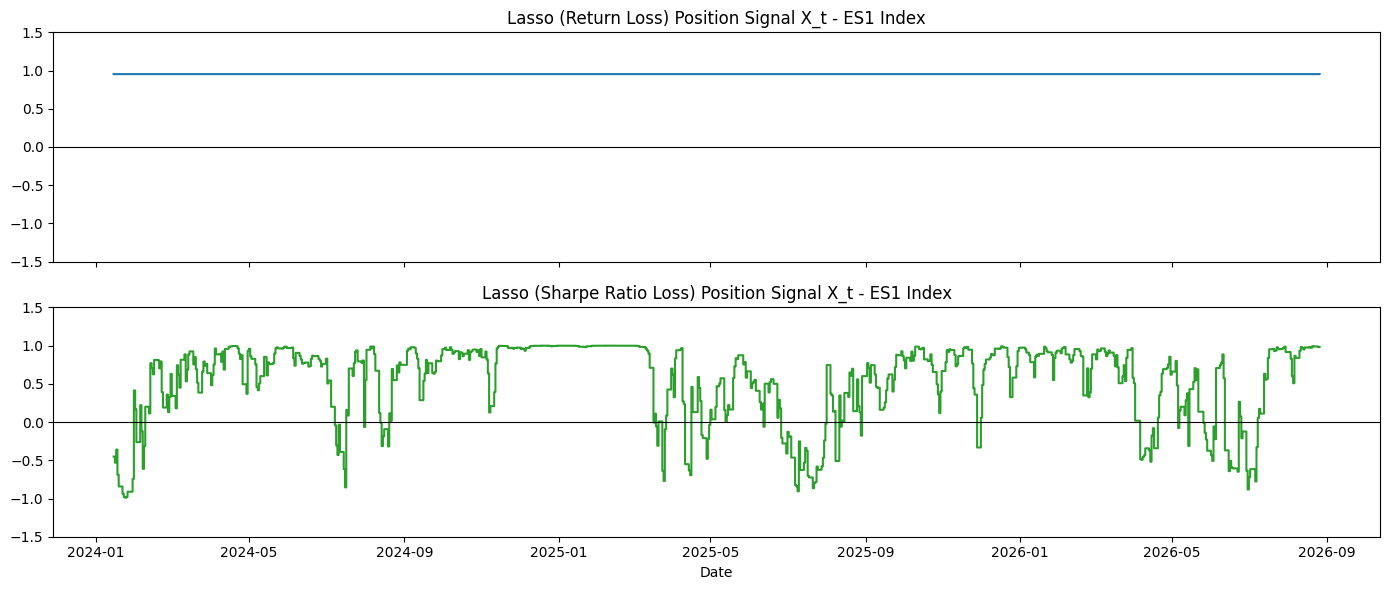

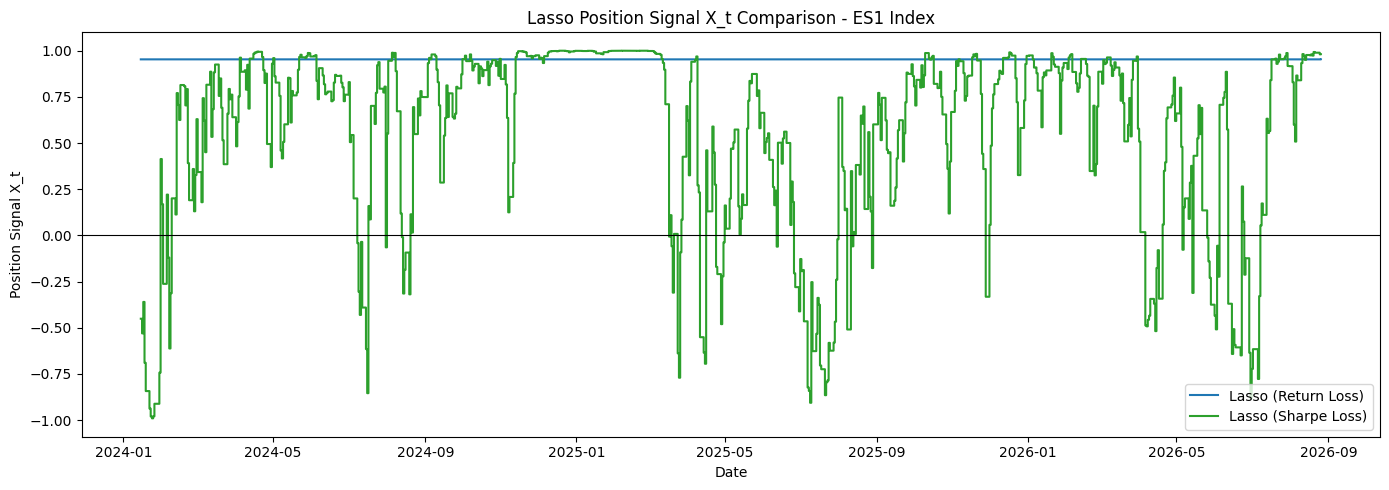

In [151]:
# Plot the Lasso trade signals (X_t) for one asset, styled like the SGN signal plot
asset = returns.columns[0]

# Recover the test-period dates (features_or/X was split by position: train, val, test)
test_dates = features_or.index[train_size + val_size:]

pred_signal_lasso_loss_df = pd.DataFrame(pred_signal_lasso_loss, index=test_dates, columns=returns.columns)
pred_signal_lasso_SR_df = pd.DataFrame(pred_signal_lasso_SR, index=test_dates, columns=returns.columns)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].step(pred_signal_lasso_loss_df.index, pred_signal_lasso_loss_df[asset], where='post', color='tab:blue')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_title(f'Lasso (Return Loss) Position Signal X_t - {asset}')

axes[1].step(pred_signal_lasso_SR_df.index, pred_signal_lasso_SR_df[asset], where='post', color='tab:green')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_title(f'Lasso (Sharpe Ratio Loss) Position Signal X_t - {asset}')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Combined comparison on one plot
plt.figure(figsize=(14, 5))
plt.step(pred_signal_lasso_loss_df.index, pred_signal_lasso_loss_df[asset], where='post', label='Lasso (Return Loss)', color='tab:blue')
plt.step(pred_signal_lasso_SR_df.index, pred_signal_lasso_SR_df[asset], where='post', label='Lasso (Sharpe Loss)', color='tab:green')
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('Date')
plt.ylabel('Position Signal X_t')
plt.title(f'Lasso Position Signal X_t Comparison - {asset}')
plt.legend()
plt.tight_layout()
plt.show()


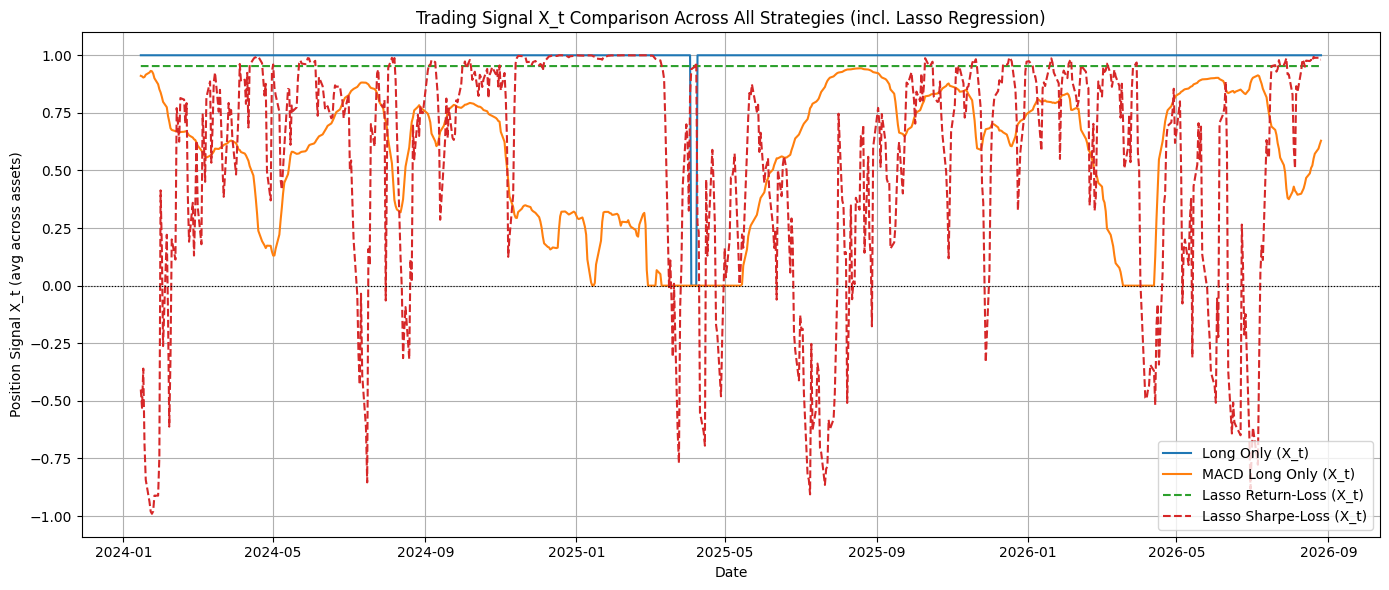

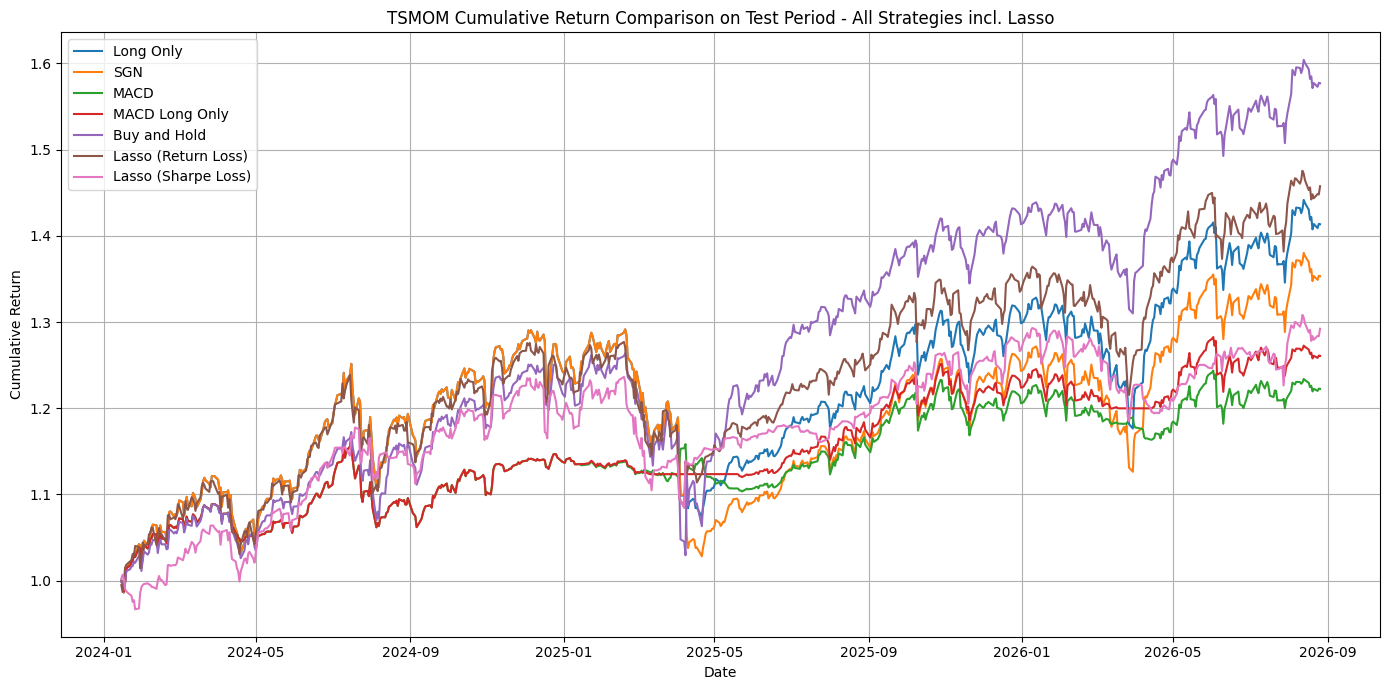

In [152]:
# All strategies together (Long, SGN, MACD, MACD Long Only, Lasso Return-Loss, Lasso Sharpe-Loss)
# 1) Plot the trading signal X_t for every strategy in one plot
# 2) Compute the TSMOM daily returns from each X_t and plot cumulative returns
# Lasso only has predictions on the TEST period, so all series are aligned to the test dates for a fair comparison

asset = returns.columns[0]
test_dates = features_or.index[train_size + val_size:]

# --- Classical signals (full sample) ---
X_long = functions.long(returns)
X_sgn = functions.SGN(returns)
X_macd = functions.calculate_cta_momentum_signal(data)
X_macd_long = functions.calculate_cta_momentum_signal_long_only(data)

# --- Lasso signals (test period only) ---
pred_signal_lasso_loss_df = pd.DataFrame(pred_signal_lasso_loss, index=test_dates, columns=returns.columns)
pred_signal_lasso_SR_df = pd.DataFrame(pred_signal_lasso_SR, index=test_dates, columns=returns.columns)

# --- Restrict the classical signals to the test period too, for a like-for-like comparison ---
X_long_test = X_long.loc[test_dates.intersection(X_long.index)]
X_sgn_test = X_sgn.loc[test_dates.intersection(X_sgn.index)]
X_macd_test = X_macd.loc[test_dates.intersection(X_macd.index)]
X_macd_long_test = X_macd_long.loc[test_dates.intersection(X_macd_long.index)]

# --- 1) Signal comparison plot (test period only) ---
plt.figure(figsize=(14, 6))
plt.plot(X_long_test.mean(axis=1), label='Long Only (X_t)')
#plt.plot(X_sgn_test.mean(axis=1), label='SGN (X_t)')
#plt.plot(X_macd_test.mean(axis=1), label='MACD (X_t)')
plt.plot(X_macd_long_test.mean(axis=1), label='MACD Long Only (X_t)')
plt.plot(pred_signal_lasso_loss_df.mean(axis=1), label='Lasso Return-Loss (X_t)', linestyle='--')
plt.plot(pred_signal_lasso_SR_df.mean(axis=1), label='Lasso Sharpe-Loss (X_t)', linestyle='--')
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.xlabel('Date')
plt.ylabel('Position Signal X_t (avg across assets)')
plt.title('Trading Signal X_t Comparison Across All Strategies (incl. Lasso Regression)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# --- 2) TSMOM daily returns from each X_t, restricted to the test period for fair comparison ---
r_Long_full = functions.TSMOM_daily(returns, data, trading_str='LONG')
r_SGN_full = functions.TSMOM_daily(returns, data, trading_str='SGN')
r_MACD_full = functions.TSMOM_daily(returns, data, trading_str='MACD')
r_MACD_LONG_full = functions.TSMOM_daily(returns, data, trading_str='MACD_LONG')
buy_and_hold_full = returns.mean(axis=1)

common_test_index = test_dates.intersection(r_Long_full.index)

r_Long_test = r_Long_full.loc[common_test_index]
r_SGN_test = r_SGN_full.loc[common_test_index]
r_MACD_test = r_MACD_full.loc[common_test_index]
r_MACD_LONG_test = r_MACD_LONG_full.loc[common_test_index]
buy_and_hold_test = buy_and_hold_full.loc[common_test_index]

avg_Lasso_loss_series = pd.Series(avg_Lasso_loss, index=test_dates)
avg_lasso_sr_series = pd.Series(avg_lasso_sr, index=test_dates)
lasso_loss_test = avg_Lasso_loss_series.loc[common_test_index]
lasso_sr_test = avg_lasso_sr_series.loc[common_test_index]

plt.figure(figsize=(14, 7))
plt.plot((r_Long_test + 1).cumprod(), label='Long Only')
plt.plot((r_SGN_test + 1).cumprod(), label='SGN')
plt.plot((r_MACD_test + 1).cumprod(), label='MACD')
plt.plot((r_MACD_LONG_test + 1).cumprod(), label='MACD Long Only')
plt.plot((buy_and_hold_test + 1).cumprod(), label='Buy and Hold')
plt.plot((lasso_loss_test + 1).cumprod(), label='Lasso (Return Loss)')
plt.plot((lasso_sr_test + 1).cumprod(), label='Lasso (Sharpe Loss)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('TSMOM Cumulative Return Comparison on Test Period - All Strategies incl. Lasso')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## Neural Layer Architecture


In [153]:
# # MLP constructions 
input_size = X_train_tf.shape[1]
output_size = returns.shape[1] 
# dropout = 0.2 
# model_mlp = functions.build_mlp(input_size, output_size, dropout)
# model_mlp.summary()
model_mlp = functions.build_mlp(input_size, output_size, loss_function="loss_return")
model_mlp_sr = functions.build_mlp(input_size, output_size, loss_function="SR")
model_mlp.summary(), model_mlp_sr.summary()

C:\Users\xuexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 80)             │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,001 (15.63 KB)

 Trainable params: 4,001 (15.63 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 80)             │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,001 (15.63 KB)

 Trainable params: 4,001 (15.63 KB)

 Non-trainable params: 0 (0.00 B)

(None, None)

In [154]:
# %%
y_train_combined_tf = tf.concat([y_train_returns_tf, y_train_sigma_tf], axis =1 )
y_val_combined_tf =  tf.concat([y_val_returns_tf, y_val_sigma_tf], axis =1 )
y_test_combined_tf = tf.concat([y_test_returns_tf, y_test_sigma_tf], axis =1)

input_size = X_train_tf.shape[1]
output_size = returns.shape[1] 
# dropout = 0.2
model_mlp = functions.build_mlp(input_size, output_size, loss_function="loss_return")
model_mlp_sr = functions.build_mlp(input_size, output_size, loss_function="SR")


# deep_model = model_mlp
epochs =100
signal_mlp, avg_TSMOM, TSMOM_returns= functions.evaluate_model(model_mlp, X_train_tf,  y_train_combined_tf, X_val_tf, y_val_combined_tf, X_test_tf, y_test_combined_tf, epochs, loss_function='loss_return')
signal_mlp_sr,  avg_TSMOM_sr, TSMOM_returns_sr = functions.evaluate_model(model_mlp_sr, X_train_tf,  y_train_combined_tf, X_val_tf, y_val_combined_tf, X_test_tf, y_test_combined_tf, epochs, loss_function='SR')

Epoch 1/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: -7.1660e-05 - val_loss: -1.4153e-04
Epoch 2/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -1.7118e-04 - val_loss: -2.1883e-04
Epoch 3/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -3.0358e-04 - val_loss: -2.8577e-04
Epoch 4/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -3.8803e-04 - val_loss: -3.1474e-04
Epoch 5/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -3.3935e-04 - val_loss: -3.3248e-04
Epoch 6/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -4.1498e-04 - val_loss: -3.5332e-04
Epoch 7/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -4.7344e-04 - val_loss: -3.6477e-04
Epoch 8/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -4.8094e-04 - val_loss: -3.1180e-04
Epoch 9/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -5.6255e-04 - val_loss: -5.0455e-04
Epoch 10/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -5.8716e-04 - val_loss: -4.3218e-04
Epoch 11/100
145/145 ━━━━━━━━

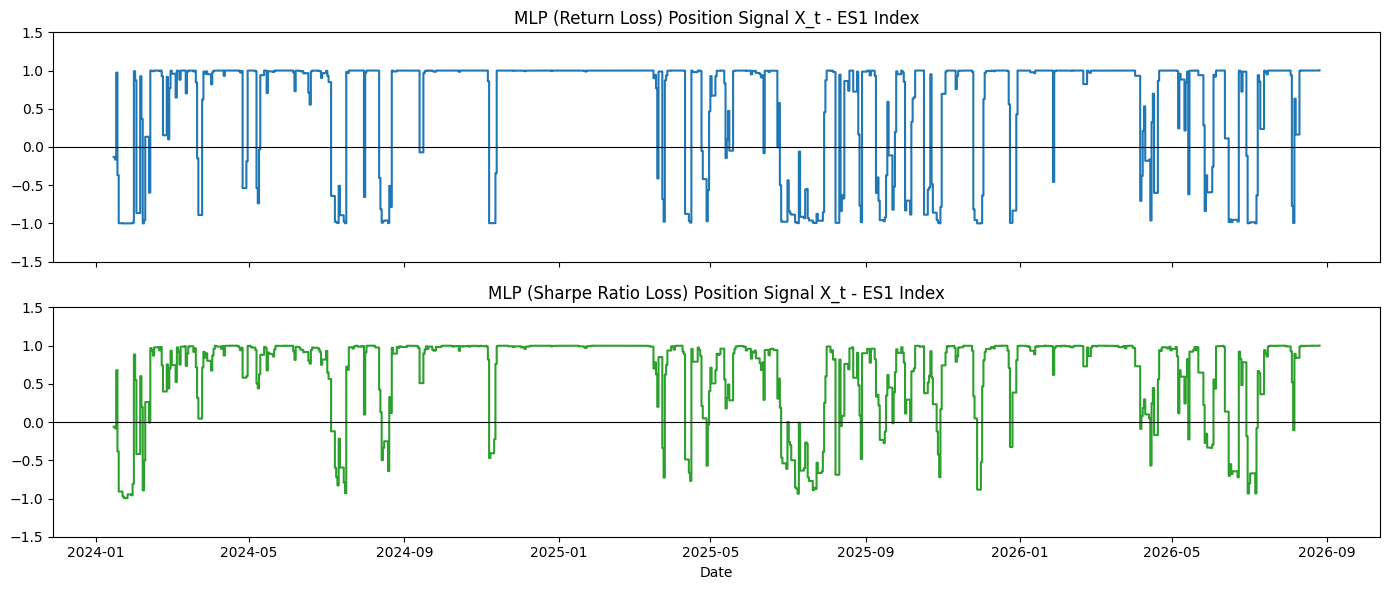

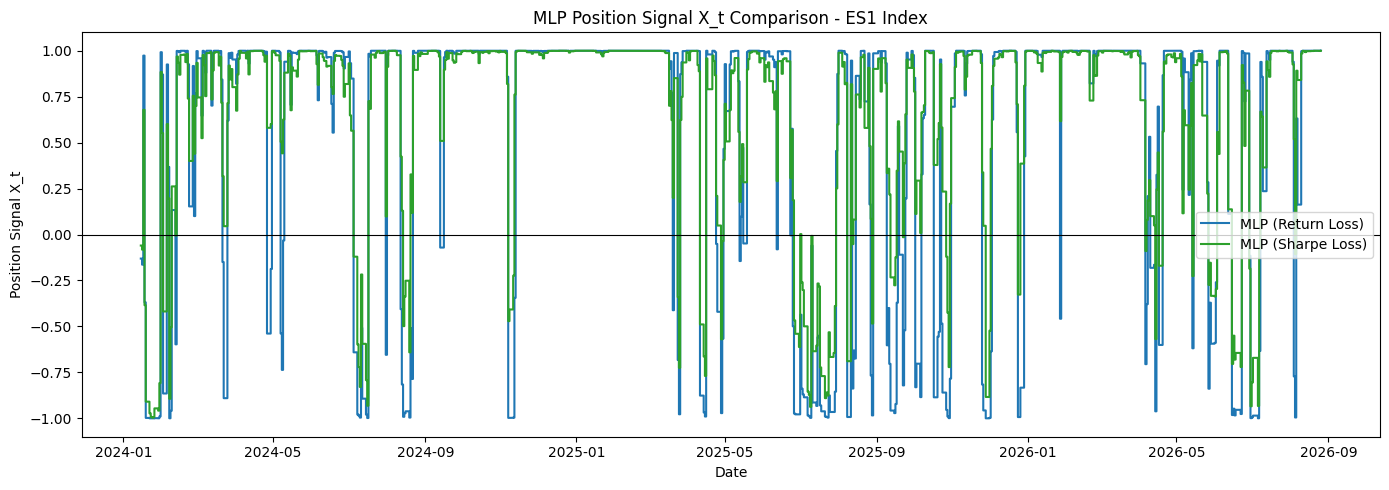

In [155]:
# Plot the MLP trade signals (X_t) for one asset, styled like the Lasso signal plot
asset = returns.columns[0]
test_dates = features_or.index[train_size + val_size:]

signal_mlp_df = pd.DataFrame(signal_mlp, index=test_dates, columns=returns.columns)
signal_mlp_sr_df = pd.DataFrame(signal_mlp_sr, index=test_dates, columns=returns.columns)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].step(signal_mlp_df.index, signal_mlp_df[asset], where='post', color='tab:blue')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_title(f'MLP (Return Loss) Position Signal X_t - {asset}')

axes[1].step(signal_mlp_sr_df.index, signal_mlp_sr_df[asset], where='post', color='tab:green')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_title(f'MLP (Sharpe Ratio Loss) Position Signal X_t - {asset}')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Combined comparison on one plot
plt.figure(figsize=(14, 5))
plt.step(signal_mlp_df.index, signal_mlp_df[asset], where='post', label='MLP (Return Loss)', color='tab:blue')
plt.step(signal_mlp_sr_df.index, signal_mlp_sr_df[asset], where='post', label='MLP (Sharpe Loss)', color='tab:green')
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('Date')
plt.ylabel('Position Signal X_t')
plt.title(f'MLP Position Signal X_t Comparison - {asset}')
plt.legend()
plt.tight_layout()
plt.show()


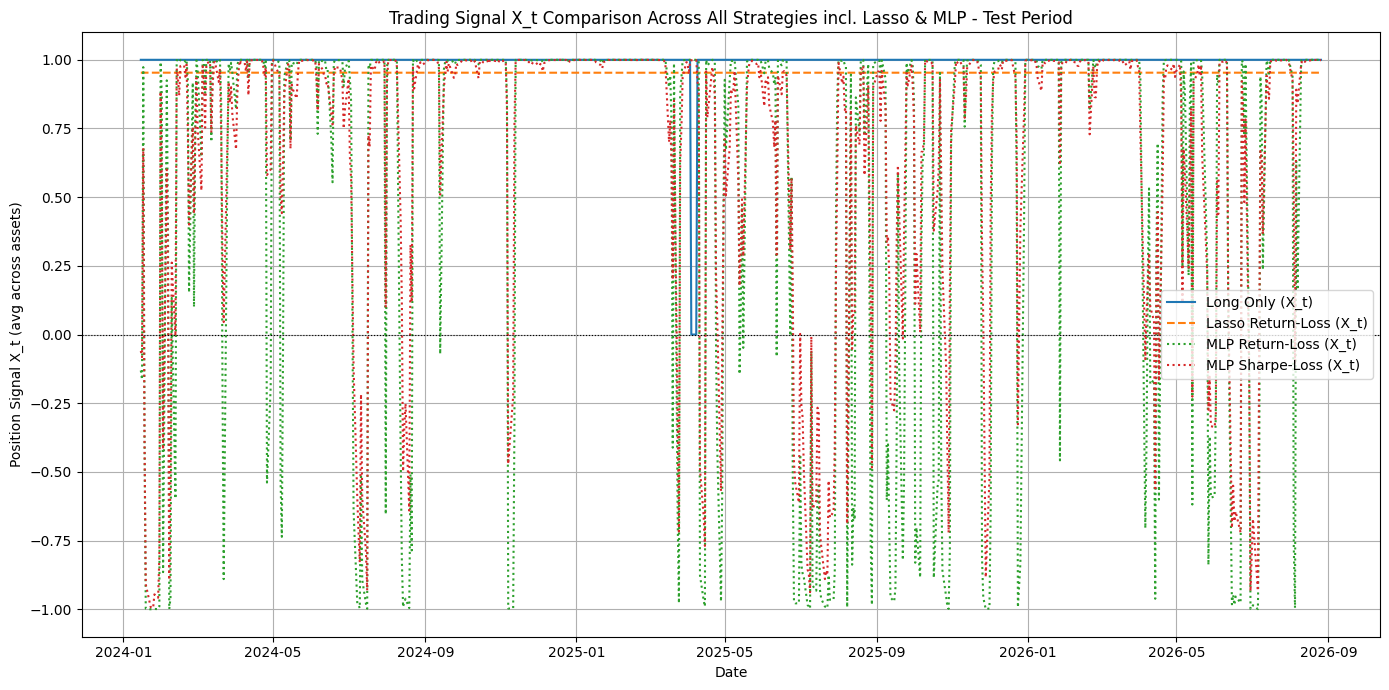

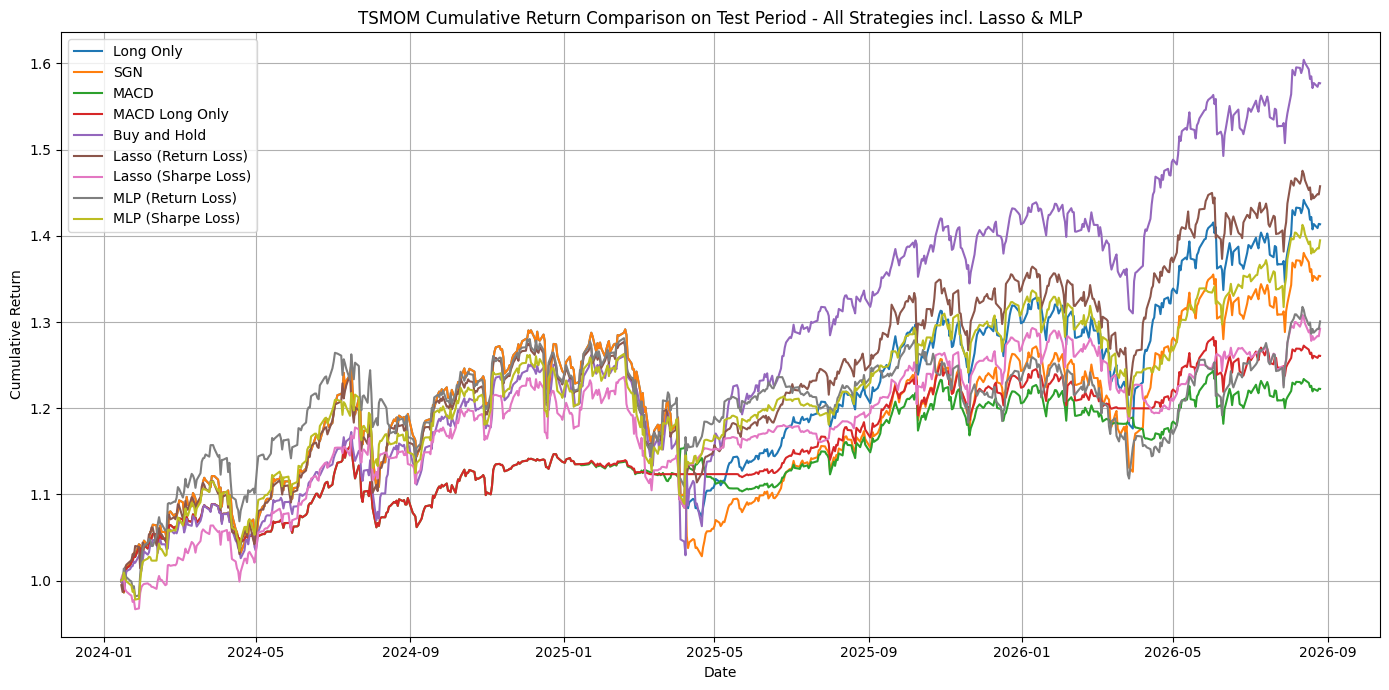

In [156]:
# All strategies together (Long, SGN, MACD, MACD Long Only, Lasso Return-Loss, Lasso Sharpe-Loss, MLP Return-Loss, MLP Sharpe-Loss)
# 1) Plot the trading signal X_t for every strategy in one plot, restricted to the TEST period
# 2) Compute the TSMOM daily returns from each X_t and plot cumulative returns over the TEST period

asset = returns.columns[0]
test_dates = features_or.index[train_size + val_size:]

# --- Classical signals (full sample), restricted to the test period ---
X_long_test = functions.long(returns).reindex(test_dates).dropna(how='all')
X_sgn_test = functions.SGN(returns).reindex(test_dates).dropna(how='all')
X_macd_test = functions.calculate_cta_momentum_signal(data).reindex(test_dates).dropna(how='all')
X_macd_long_test = functions.calculate_cta_momentum_signal_long_only(data).reindex(test_dates).dropna(how='all')

# --- Lasso signals (already test-period only) ---
lasso_loss_signal_df = pd.DataFrame(pred_signal_lasso_loss, index=test_dates, columns=returns.columns)
lasso_sr_signal_df = pd.DataFrame(pred_signal_lasso_SR, index=test_dates, columns=returns.columns)

# --- MLP signals (already test-period only) ---
mlp_loss_signal_df = pd.DataFrame(signal_mlp, index=test_dates, columns=returns.columns)
mlp_sr_signal_df = pd.DataFrame(signal_mlp_sr, index=test_dates, columns=returns.columns)

# --- 1) Signal comparison plot (test period only) ---
plt.figure(figsize=(14, 7))
plt.plot(X_long_test.mean(axis=1), label='Long Only (X_t)')
# plt.plot(X_sgn_test.mean(axis=1), label='SGN (X_t)')
# plt.plot(X_macd_test.mean(axis=1), label='MACD (X_t)')
# plt.plot(X_macd_long_test.mean(axis=1), label='MACD Long Only (X_t)')
plt.plot(lasso_loss_signal_df.mean(axis=1), label='Lasso Return-Loss (X_t)', linestyle='--')
# plt.plot(lasso_sr_signal_df.mean(axis=1), label='Lasso Sharpe-Loss (X_t)', linestyle='--')
plt.plot(mlp_loss_signal_df.mean(axis=1), label='MLP Return-Loss (X_t)', linestyle=':')
plt.plot(mlp_sr_signal_df.mean(axis=1), label='MLP Sharpe-Loss (X_t)', linestyle=':')
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.xlabel('Date')
plt.ylabel('Position Signal X_t (avg across assets)')
plt.title('Trading Signal X_t Comparison Across All Strategies incl. Lasso & MLP - Test Period')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# --- 2) TSMOM daily returns from each X_t, restricted to the test period for fair comparison ---
r_Long_full = functions.TSMOM_daily(returns, data, trading_str='LONG')
r_SGN_full = functions.TSMOM_daily(returns, data, trading_str='SGN')
r_MACD_full = functions.TSMOM_daily(returns, data, trading_str='MACD')
r_MACD_LONG_full = functions.TSMOM_daily(returns, data, trading_str='MACD_LONG')
buy_and_hold_full = returns.mean(axis=1)

common_test_index = test_dates.intersection(r_Long_full.index)

r_Long_test = r_Long_full.loc[common_test_index]
r_SGN_test = r_SGN_full.loc[common_test_index]
r_MACD_test = r_MACD_full.loc[common_test_index]
r_MACD_LONG_test = r_MACD_LONG_full.loc[common_test_index]
buy_and_hold_test = buy_and_hold_full.loc[common_test_index]

avg_Lasso_loss_series = pd.Series(avg_Lasso_loss, index=test_dates)
avg_lasso_sr_series = pd.Series(avg_lasso_sr, index=test_dates)
avg_mlp_loss_series = pd.Series(avg_TSMOM, index=test_dates)
avg_mlp_sr_series = pd.Series(avg_TSMOM_sr, index=test_dates)

lasso_loss_test = avg_Lasso_loss_series.loc[common_test_index]
lasso_sr_test = avg_lasso_sr_series.loc[common_test_index]
mlp_loss_test = avg_mlp_loss_series.loc[common_test_index]
mlp_sr_test = avg_mlp_sr_series.loc[common_test_index]

plt.figure(figsize=(14, 7))
plt.plot((r_Long_test + 1).cumprod(), label='Long Only')
plt.plot((r_SGN_test + 1).cumprod(), label='SGN')
plt.plot((r_MACD_test + 1).cumprod(), label='MACD')
plt.plot((r_MACD_LONG_test + 1).cumprod(), label='MACD Long Only')
plt.plot((buy_and_hold_test + 1).cumprod(), label='Buy and Hold')
plt.plot((lasso_loss_test + 1).cumprod(), label='Lasso (Return Loss)')
plt.plot((lasso_sr_test + 1).cumprod(), label='Lasso (Sharpe Loss)')
plt.plot((mlp_loss_test + 1).cumprod(), label='MLP (Return Loss)')
plt.plot((mlp_sr_test + 1).cumprod(), label='MLP (Sharpe Loss)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('TSMOM Cumulative Return Comparison on Test Period - All Strategies incl. Lasso & MLP')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


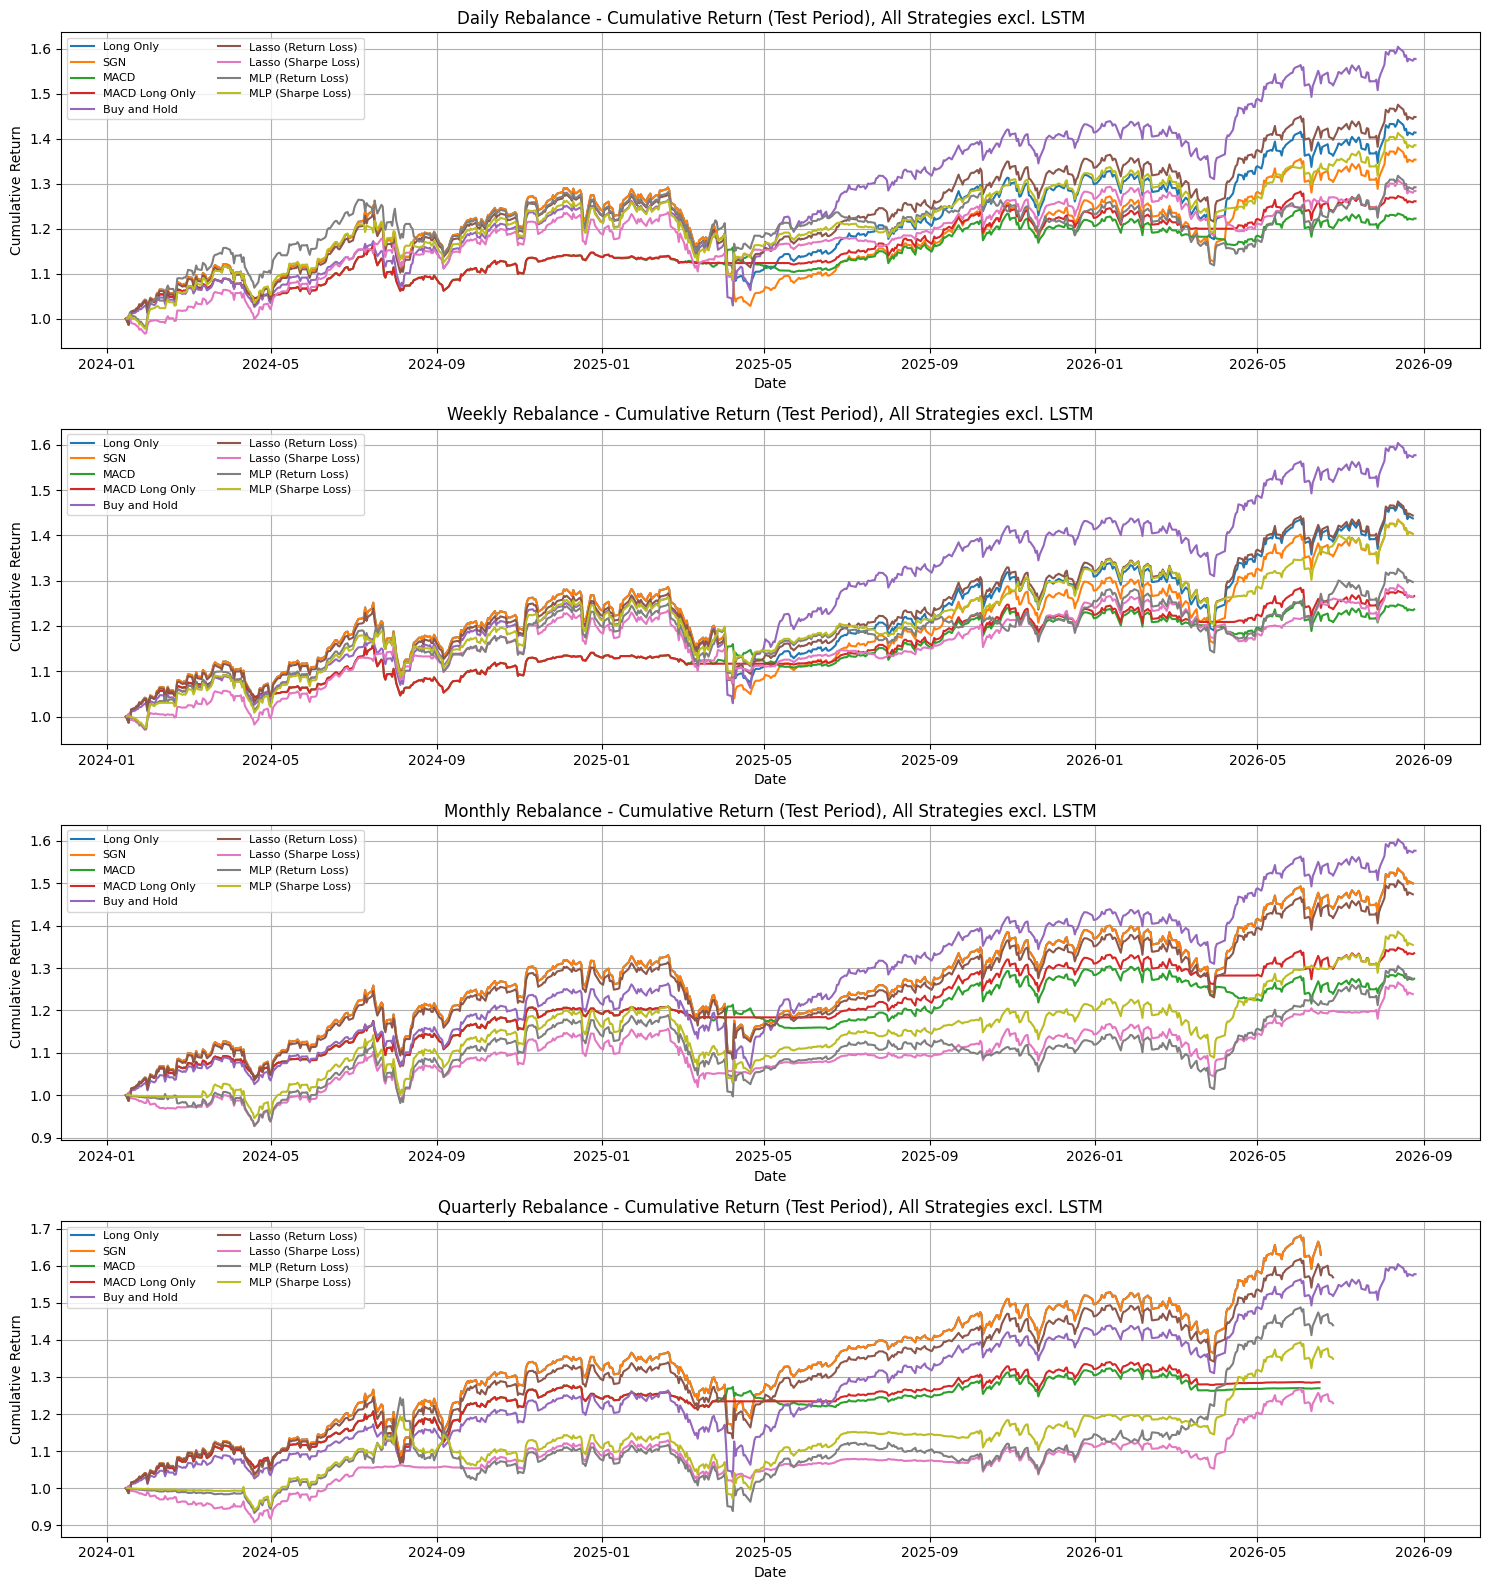

In [157]:
# Daily / Weekly / Monthly / Quarterly rebalancing comparison across ALL strategies except LSTM
# (Long, SGN, MACD, MACD Long Only, Buy+Hold, Lasso Return-Loss, Lasso Sharpe-Loss, MLP Return-Loss, MLP Sharpe-Loss)
# restricted to the test period, so Lasso/MLP (which only have test-period predictions) can be compared fairly.

test_dates = features_or.index[train_size + val_size:]

# --- Lasso/MLP signals as date-indexed DataFrames (test period only) ---
lasso_loss_signal_df = pd.DataFrame(pred_signal_lasso_loss, index=test_dates, columns=returns.columns)
lasso_sr_signal_df = pd.DataFrame(pred_signal_lasso_SR, index=test_dates, columns=returns.columns)
mlp_loss_signal_df = pd.DataFrame(signal_mlp, index=test_dates, columns=returns.columns)
mlp_sr_signal_df = pd.DataFrame(signal_mlp_sr, index=test_dates, columns=returns.columns)

freqs = {'Daily': 1, 'Weekly': 4, 'Monthly': 20, 'Quarterly': 62}

fig, axes = plt.subplots(len(freqs), 1, figsize=(15, 16), sharex=False)

for ax, (freq_name, freq) in zip(axes, freqs.items()):
    r_long = functions.TSMOM_rebalance(returns, data, trading_str='LONG', freq_balance=freq)
    r_sgn = functions.TSMOM_rebalance(returns, data, trading_str='SGN', freq_balance=freq)
    r_macd = functions.TSMOM_rebalance(returns, data, trading_str='MACD', freq_balance=freq)
    r_macd_long = functions.TSMOM_rebalance(returns, data, trading_str='MACD_LONG', freq_balance=freq)
    r_lasso_loss = functions.TSMOM_rebalance_signal(returns, lasso_loss_signal_df, freq_balance=freq)
    r_lasso_sr = functions.TSMOM_rebalance_signal(returns, lasso_sr_signal_df, freq_balance=freq)
    r_mlp_loss = functions.TSMOM_rebalance_signal(returns, mlp_loss_signal_df, freq_balance=freq)
    r_mlp_sr = functions.TSMOM_rebalance_signal(returns, mlp_sr_signal_df, freq_balance=freq)
    buy_and_hold = returns.mean(axis=1)

    # Each strategy's signal can start on a different date (e.g. MACD needs a longer rolling window
    # than LONG/SGN), so intersect every series with test_dates individually rather than assuming
    # they all share the same index.
    ax.plot((r_long.loc[test_dates.intersection(r_long.index)] + 1).cumprod(), label='Long Only')
    ax.plot((r_sgn.loc[test_dates.intersection(r_sgn.index)] + 1).cumprod(), label='SGN')
    ax.plot((r_macd.loc[test_dates.intersection(r_macd.index)] + 1).cumprod(), label='MACD')
    ax.plot((r_macd_long.loc[test_dates.intersection(r_macd_long.index)] + 1).cumprod(), label='MACD Long Only')
    ax.plot((buy_and_hold.loc[test_dates.intersection(buy_and_hold.index)] + 1).cumprod(), label='Buy and Hold')
    ax.plot((r_lasso_loss.loc[test_dates.intersection(r_lasso_loss.index)] + 1).cumprod(), label='Lasso (Return Loss)')
    ax.plot((r_lasso_sr.loc[test_dates.intersection(r_lasso_sr.index)] + 1).cumprod(), label='Lasso (Sharpe Loss)')
    ax.plot((r_mlp_loss.loc[test_dates.intersection(r_mlp_loss.index)] + 1).cumprod(), label='MLP (Return Loss)')
    ax.plot((r_mlp_sr.loc[test_dates.intersection(r_mlp_sr.index)] + 1).cumprod(), label='MLP (Sharpe Loss)')

    ax.set_title(f'{freq_name} Rebalance - Cumulative Return (Test Period), All Strategies excl. LSTM')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return')
    ax.legend(ncol=2, fontsize=8)
    ax.grid()

plt.tight_layout()
plt.show()



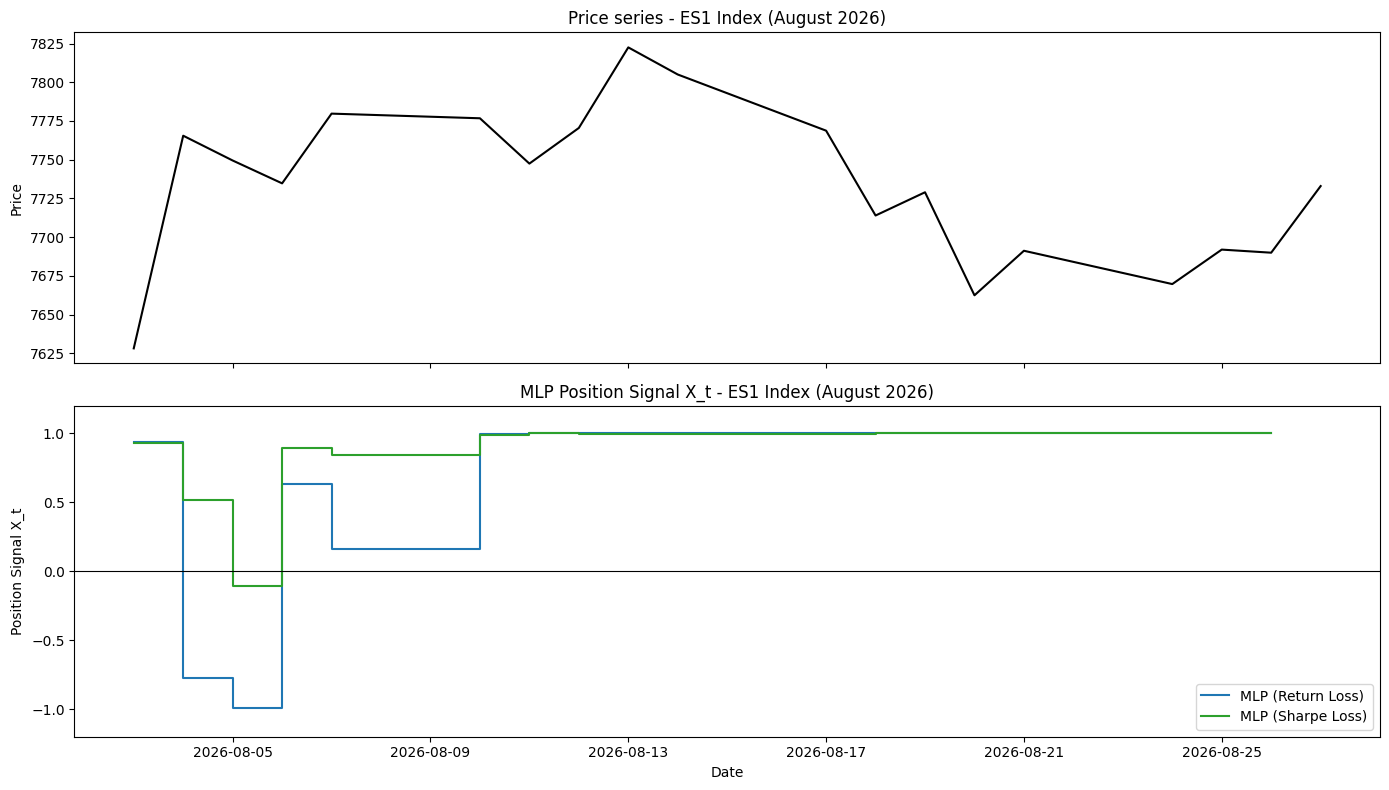

In [158]:
# Price vs MLP position signal X_t (Return-Loss and Sharpe-Loss), limited to August 2026
asset = returns.columns[0]
start_date = '2026-08-01'
end_date = '2026-08-27'

data_period = data.loc[start_date:end_date]
mlp_loss_signal_period = mlp_loss_signal_df.loc[start_date:end_date]
mlp_sr_signal_period = mlp_sr_signal_df.loc[start_date:end_date]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(data_period.index, data_period[asset], color='black')
axes[0].set_title(f'Price series - {asset} (August 2026)')
axes[0].set_ylabel('Price')

axes[1].step(mlp_loss_signal_period.index, mlp_loss_signal_period[asset], where='post',
             label='MLP (Return Loss)', color='tab:blue')
axes[1].step(mlp_sr_signal_period.index, mlp_sr_signal_period[asset], where='post',
             label='MLP (Sharpe Loss)', color='tab:green')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylim(-1.2, 1.2)
axes[1].set_title(f'MLP Position Signal X_t - {asset} (August 2026)')
axes[1].set_ylabel('Position Signal X_t')
axes[1].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()


In [159]:
# %%
# LSTM construction
input_shape = X_train_seq
output_shape = returns.shape[1] 
dropout = 0.2
model_lstm = functions.build_LSTM(input_shape, output_shape, dropout, seq_length=seq_length)
model_lstm.summary()

C:\Users\xuexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 252, 128)       │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 252, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 80)             │        66,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,305 (548.07 KB)

 Trainable params: 140,305 (548.07 KB)

 Non-trainable params: 0 (0.00 B)

In [160]:
# %%
input_shape = X_train_seq
output_shape = returns.shape[1] 
dropout = 0.2
model_lstm = functions.build_LSTM(input_shape, output_shape, dropout, seq_length=seq_length)

epochs =100
signal_mlp_lstm, avg_TSMOM_lstm, TSMOM_returns_lstm= functions.evaluate_model(model_lstm, X_train_seq,  y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, epochs, loss_function='loss_return')
# %%
input_shape = X_train_seq
output_shape = returns.shape[1] 
dropout = 0.2
model_lstm_sr  = functions.build_LSTM(input_shape, output_shape, dropout, seq_length=seq_length)
signal_mlp_lstm_sr,  avg_TSMOM_lstm_sr, TSMOM_returns_lstm_sr = functions.evaluate_model(model_lstm_sr, X_train_seq,  y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, epochs, loss_function='SR')

Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: -1.3446e-04 - val_loss: -1.1068e-04
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - loss: -2.2242e-04 - val_loss: -1.8394e-04
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - loss: -2.2875e-04 - val_loss: -3.4331e-04
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - loss: -2.4542e-04 - val_loss: -1.4576e-05
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - loss: -2.5691e-04 - val_loss: 1.7026e-04
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - loss: -5.4728e-05 - val_loss: -3.4906e-04
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - loss: -2.8181e-04 - val_loss: -6.1287e-05
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - loss: -2.3246e-04 - val_loss: -2.5744e-04
Epoch 9/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 112ms/step - loss: -2.9942e-04 - val_loss: -2.9769e-05
Epoch 10/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - loss: -3.5043e-04 - val_loss: -2.7146e-04


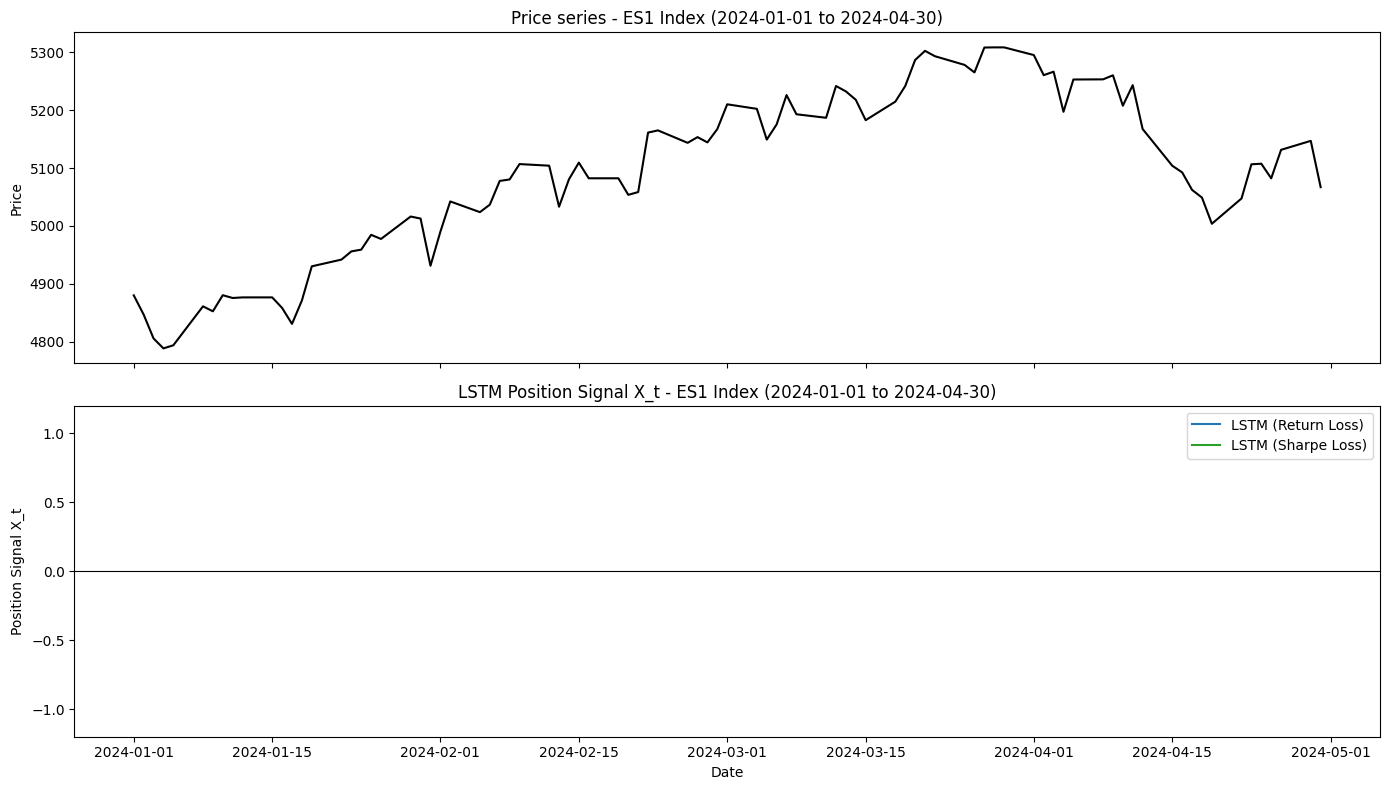

In [161]:
# Price vs LSTM position signal X_t (Return-Loss and Sharpe-Loss), for a period YOU can set below
asset = returns.columns[0]

# --- Set your own inspection window here ---
start_date = '2024-01-01'
end_date = '2024-04-30'

# create_sequences drops the first (seq_length - 1) rows, so LSTM predictions align to test_dates
# starting at index (seq_length - 1); wrap the raw array output into date-indexed DataFrames first.
test_dates_lstm = test_dates[seq_length - 1:]
signal_lstm_df = pd.DataFrame(signal_mlp_lstm, index=test_dates_lstm, columns=returns.columns)
signal_lstm_sr_df = pd.DataFrame(signal_mlp_lstm_sr, index=test_dates_lstm, columns=returns.columns)

data_period = data.loc[start_date:end_date]
lstm_loss_signal_period = signal_lstm_df.loc[start_date:end_date]
lstm_sr_signal_period = signal_lstm_sr_df.loc[start_date:end_date]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(data_period.index, data_period[asset], color='black')
axes[0].set_title(f'Price series - {asset} ({start_date} to {end_date})')
axes[0].set_ylabel('Price')

axes[1].step(lstm_loss_signal_period.index, lstm_loss_signal_period[asset], where='post',
             label='LSTM (Return Loss)', color='tab:blue')
axes[1].step(lstm_sr_signal_period.index, lstm_sr_signal_period[asset], where='post',
             label='LSTM (Sharpe Loss)', color='tab:green')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylim(-1.2, 1.2)
axes[1].set_title(f'LSTM Position Signal X_t - {asset} ({start_date} to {end_date})')
axes[1].set_ylabel('Position Signal X_t')
axes[1].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()


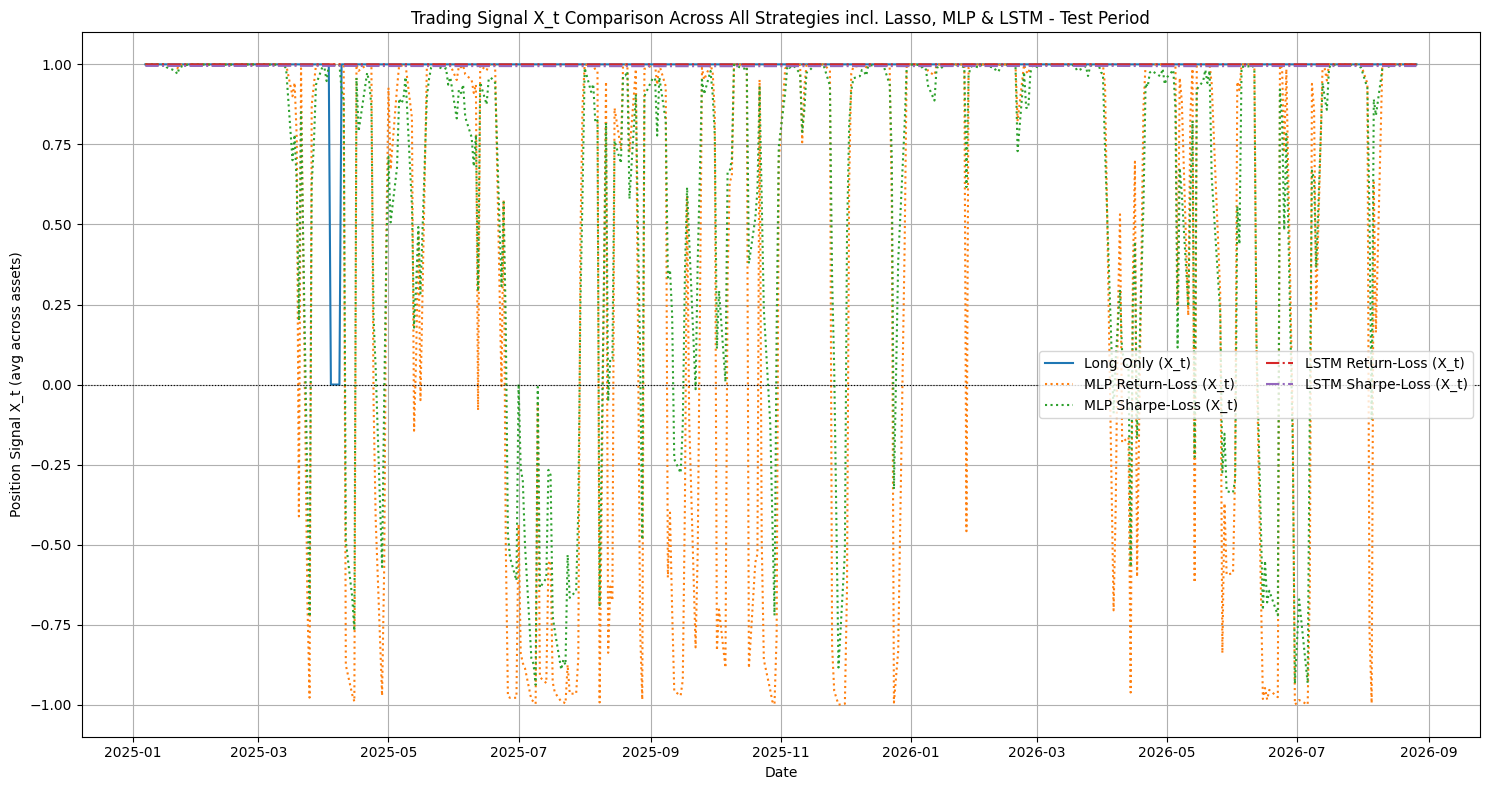

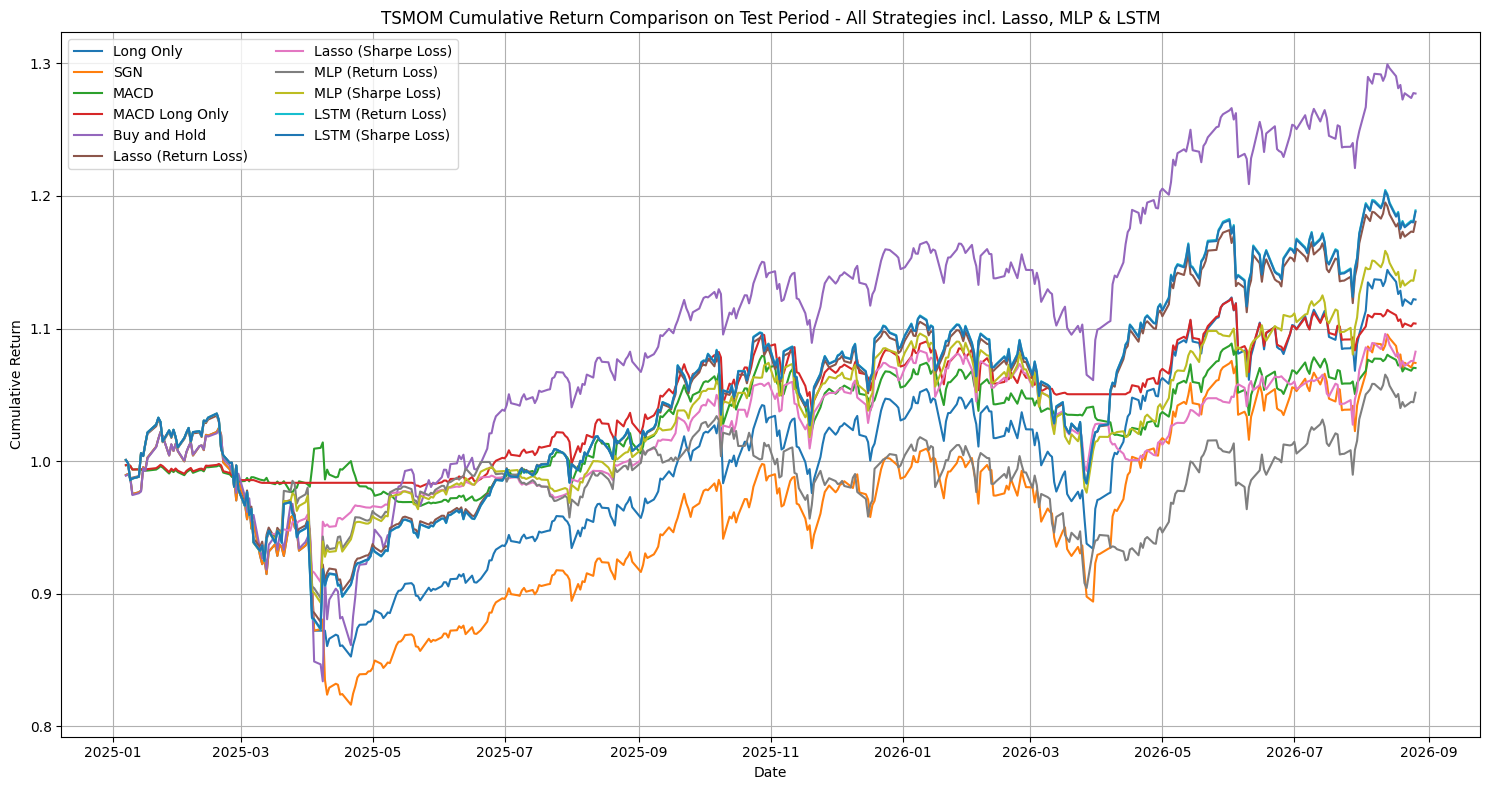

In [162]:
# Full comparison across ALL strategies (Long, SGN, MACD, MACD Long Only, Lasso Return-Loss, Lasso Sharpe-Loss,
# MLP Return-Loss, MLP Sharpe-Loss, LSTM Return-Loss, LSTM Sharpe-Loss), restricted to the TEST period only.
# 1) Plot the trading signal X_t for every strategy in one plot (test period)
# 2) Compute the TSMOM daily returns from each X_t and plot cumulative returns (test period)
# LSTM predictions start (seq_length - 1) days later than the other test-period series (create_sequences
# needs seq_length lookback points), so LSTM series are aligned on test_dates_lstm and everything is
# intersected onto a common index for a fair like-for-like comparison.

asset = returns.columns[0]
test_dates = features_or.index[train_size + val_size:]
test_dates_lstm = test_dates[seq_length - 1:]

# --- Classical signals, restricted to the test period ---
X_long_test = functions.long(returns).reindex(test_dates).dropna(how='all')
X_sgn_test = functions.SGN(returns).reindex(test_dates).dropna(how='all')
X_macd_test = functions.calculate_cta_momentum_signal(data).reindex(test_dates).dropna(how='all')
X_macd_long_test = functions.calculate_cta_momentum_signal_long_only(data).reindex(test_dates).dropna(how='all')

# --- Lasso signals (already test-period only) ---
lasso_loss_signal_df = pd.DataFrame(pred_signal_lasso_loss, index=test_dates, columns=returns.columns)
lasso_sr_signal_df = pd.DataFrame(pred_signal_lasso_SR, index=test_dates, columns=returns.columns)

# --- MLP signals (already test-period only) ---
mlp_loss_signal_df = pd.DataFrame(signal_mlp, index=test_dates, columns=returns.columns)
mlp_sr_signal_df = pd.DataFrame(signal_mlp_sr, index=test_dates, columns=returns.columns)

# --- LSTM signals (test period, shifted by seq_length - 1) ---
lstm_loss_signal_df = pd.DataFrame(signal_mlp_lstm, index=test_dates_lstm, columns=returns.columns)
lstm_sr_signal_df = pd.DataFrame(signal_mlp_lstm_sr, index=test_dates_lstm, columns=returns.columns)

# Restrict every signal series to the common LSTM test period (shortest window) for a fair comparison
common_signal_index = test_dates_lstm.intersection(X_long_test.index)
X_long_test = X_long_test.loc[common_signal_index]
X_sgn_test = X_sgn_test.loc[test_dates_lstm.intersection(X_sgn_test.index)]
X_macd_test = X_macd_test.loc[test_dates_lstm.intersection(X_macd_test.index)]
X_macd_long_test = X_macd_long_test.loc[test_dates_lstm.intersection(X_macd_long_test.index)]
lasso_loss_signal_df = lasso_loss_signal_df.loc[common_signal_index]
lasso_sr_signal_df = lasso_sr_signal_df.loc[common_signal_index]
mlp_loss_signal_df = mlp_loss_signal_df.loc[common_signal_index]
mlp_sr_signal_df = mlp_sr_signal_df.loc[common_signal_index]
lstm_loss_signal_df = lstm_loss_signal_df.loc[common_signal_index]
lstm_sr_signal_df = lstm_sr_signal_df.loc[common_signal_index]

# --- 1) Signal comparison plot (LSTM test period only) ---
plt.figure(figsize=(15, 8))
plt.plot(X_long_test.mean(axis=1), label='Long Only (X_t)')
# plt.plot(X_sgn_test.mean(axis=1), label='SGN (X_t)')
# plt.plot(X_macd_test.mean(axis=1), label='MACD (X_t)')
# plt.plot(X_macd_long_test.mean(axis=1), label='MACD Long Only (X_t)')
# plt.plot(lasso_loss_signal_df.mean(axis=1), label='Lasso Return-Loss (X_t)', linestyle='--')
# plt.plot(lasso_sr_signal_df.mean(axis=1), label='Lasso Sharpe-Loss (X_t)', linestyle='--')
plt.plot(mlp_loss_signal_df.mean(axis=1), label='MLP Return-Loss (X_t)', linestyle=':')
plt.plot(mlp_sr_signal_df.mean(axis=1), label='MLP Sharpe-Loss (X_t)', linestyle=':')
plt.plot(lstm_loss_signal_df.mean(axis=1), label='LSTM Return-Loss (X_t)', linestyle='-.')
plt.plot(lstm_sr_signal_df.mean(axis=1), label='LSTM Sharpe-Loss (X_t)', linestyle='-.')
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.xlabel('Date')
plt.ylabel('Position Signal X_t (avg across assets)')
plt.title('Trading Signal X_t Comparison Across All Strategies incl. Lasso, MLP & LSTM - Test Period')
plt.legend(ncol=2)
plt.grid()
plt.tight_layout()
plt.show()

# --- 2) TSMOM daily returns from each X_t, restricted to the common test period for fair comparison ---
r_Long_full = functions.TSMOM_daily(returns, data, trading_str='LONG')
r_SGN_full = functions.TSMOM_daily(returns, data, trading_str='SGN')
r_MACD_full = functions.TSMOM_daily(returns, data, trading_str='MACD')
r_MACD_LONG_full = functions.TSMOM_daily(returns, data, trading_str='MACD_LONG')
buy_and_hold_full = returns.mean(axis=1)

# Use the LSTM dates as the common index since it's the shortest (starts latest)
common_test_index = test_dates_lstm.intersection(r_Long_full.index)

r_Long_test = r_Long_full.loc[common_test_index]
r_SGN_test = r_SGN_full.loc[common_test_index]
r_MACD_test = r_MACD_full.loc[common_test_index]
r_MACD_LONG_test = r_MACD_LONG_full.loc[common_test_index]
buy_and_hold_test = buy_and_hold_full.loc[common_test_index]

avg_Lasso_loss_series = pd.Series(avg_Lasso_loss, index=test_dates)
avg_lasso_sr_series = pd.Series(avg_lasso_sr, index=test_dates)
avg_mlp_loss_series = pd.Series(avg_TSMOM, index=test_dates)
avg_mlp_sr_series = pd.Series(avg_TSMOM_sr, index=test_dates)
avg_lstm_loss_series = pd.Series(avg_TSMOM_lstm, index=test_dates_lstm)
avg_lstm_sr_series = pd.Series(avg_TSMOM_lstm_sr, index=test_dates_lstm)

lasso_loss_test = avg_Lasso_loss_series.loc[common_test_index]
lasso_sr_test = avg_lasso_sr_series.loc[common_test_index]
mlp_loss_test = avg_mlp_loss_series.loc[common_test_index]
mlp_sr_test = avg_mlp_sr_series.loc[common_test_index]
lstm_loss_test = avg_lstm_loss_series.loc[common_test_index]
lstm_sr_test = avg_lstm_sr_series.loc[common_test_index]

plt.figure(figsize=(15, 8))
plt.plot((r_Long_test + 1).cumprod(), label='Long Only')
plt.plot((r_SGN_test + 1).cumprod(), label='SGN')
plt.plot((r_MACD_test + 1).cumprod(), label='MACD')
plt.plot((r_MACD_LONG_test + 1).cumprod(), label='MACD Long Only')
plt.plot((buy_and_hold_test + 1).cumprod(), label='Buy and Hold')
plt.plot((lasso_loss_test + 1).cumprod(), label='Lasso (Return Loss)')
plt.plot((lasso_sr_test + 1).cumprod(), label='Lasso (Sharpe Loss)')
plt.plot((mlp_loss_test + 1).cumprod(), label='MLP (Return Loss)')
plt.plot((mlp_sr_test + 1).cumprod(), label='MLP (Sharpe Loss)')
plt.plot((lstm_loss_test + 1).cumprod(), label='LSTM (Return Loss)')
plt.plot((lstm_sr_test + 1).cumprod(), label='LSTM (Sharpe Loss)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('TSMOM Cumulative Return Comparison on Test Period - All Strategies incl. Lasso, MLP & LSTM')
plt.legend(ncol=2)
plt.grid()
plt.tight_layout()
plt.show()


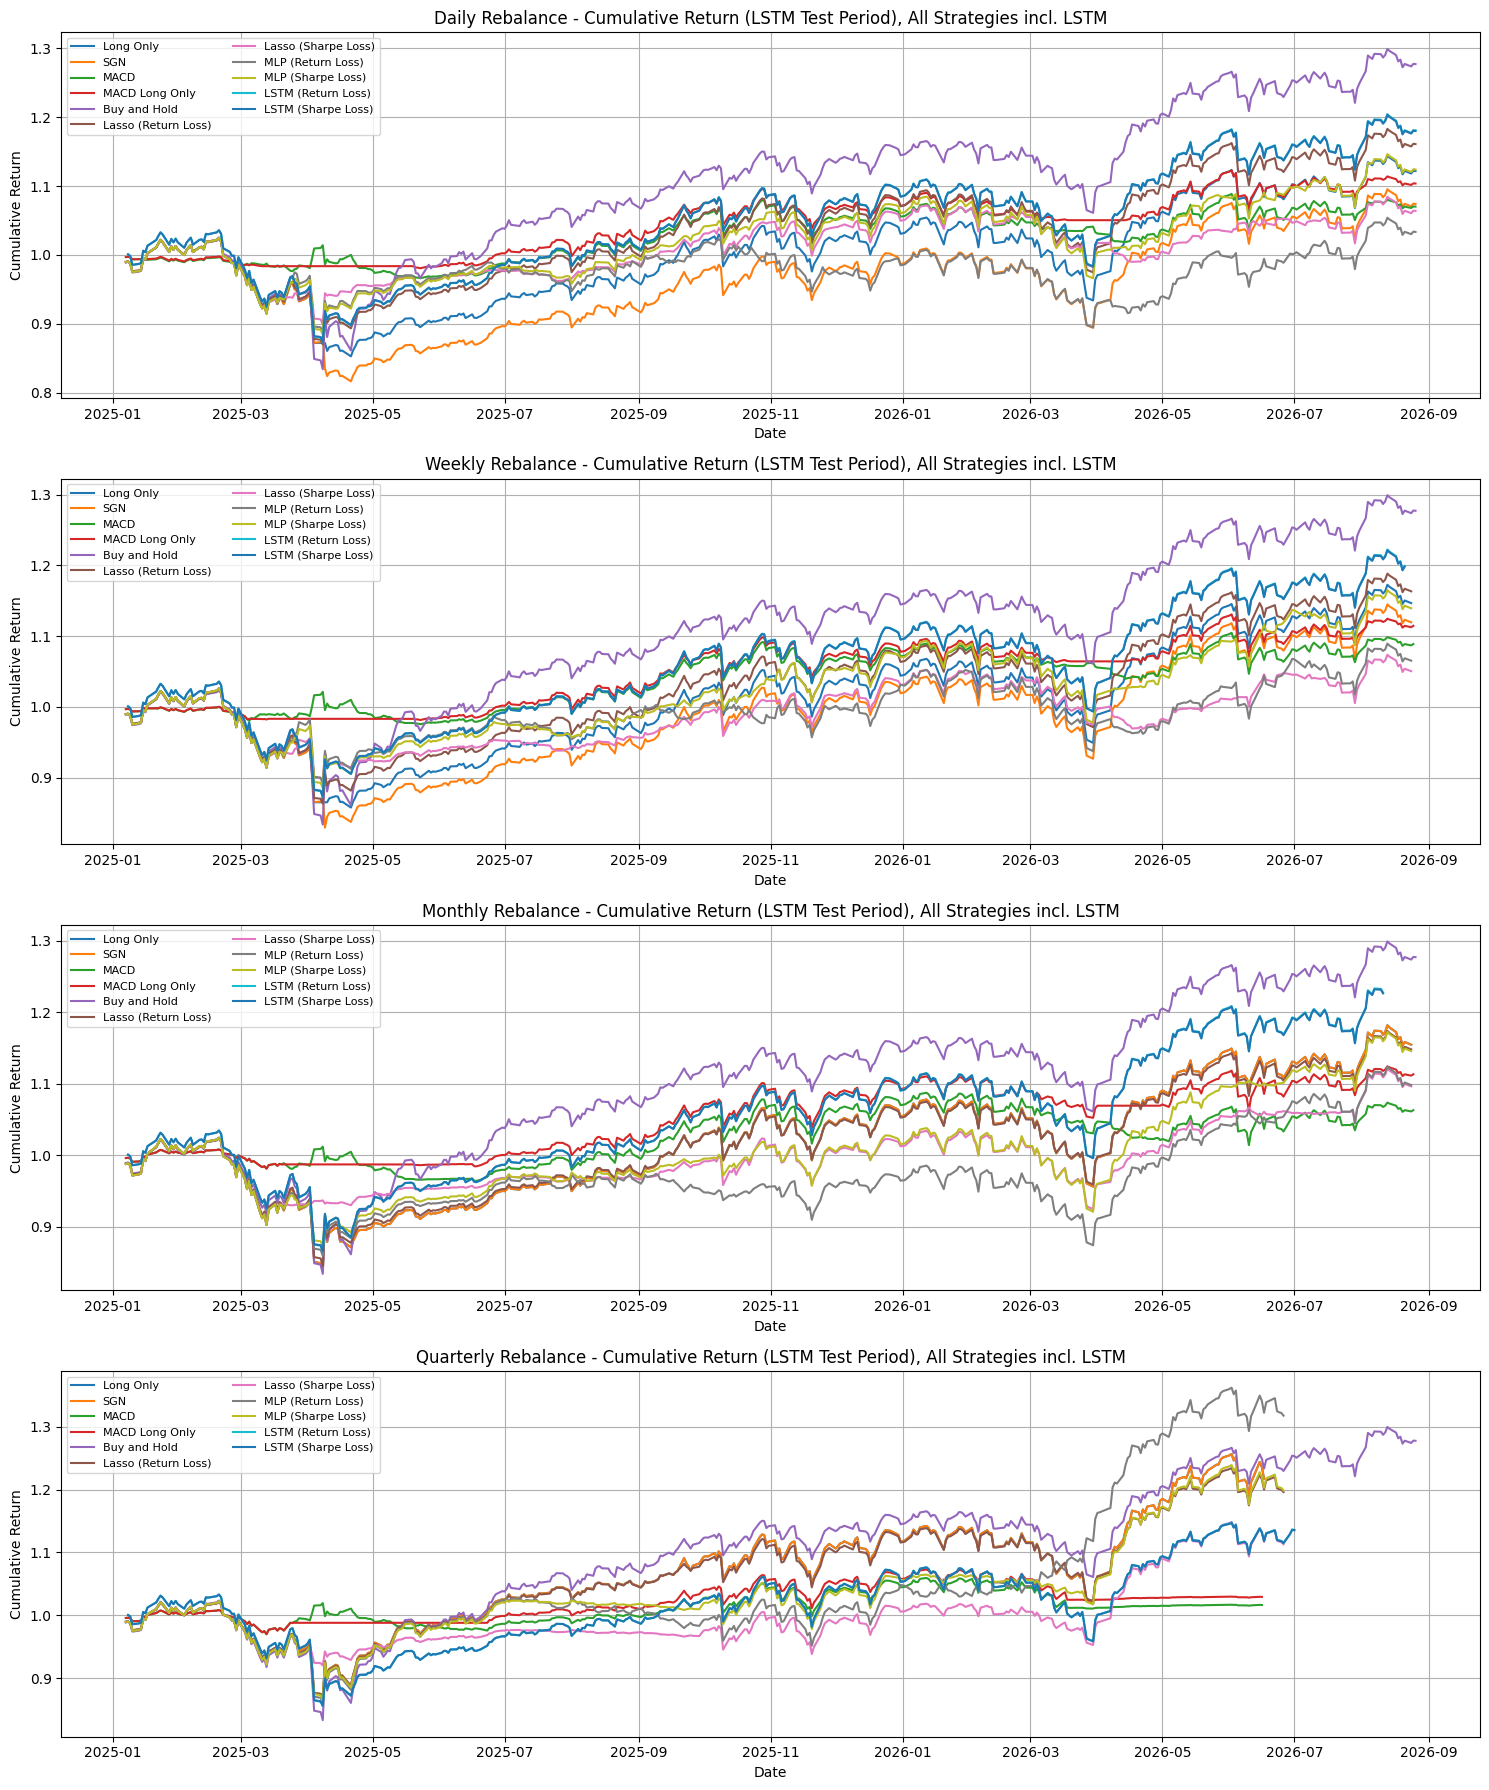

In [163]:
# Daily / Weekly / Monthly / Quarterly rebalancing comparison across ALL strategies INCLUDING LSTM
# (Long, SGN, MACD, MACD Long Only, Buy+Hold, Lasso Return-Loss, Lasso Sharpe-Loss,
# MLP Return-Loss, MLP Sharpe-Loss, LSTM Return-Loss, LSTM Sharpe-Loss).
# LSTM predictions start (seq_length - 1) days later than the other test-period series, so every
# strategy is restricted to test_dates_lstm (the shortest common window) for a fair comparison.

test_dates = features_or.index[train_size + val_size:]
test_dates_lstm = test_dates[seq_length - 1:]

# --- Lasso/MLP/LSTM signals as date-indexed DataFrames ---
lasso_loss_signal_df = pd.DataFrame(pred_signal_lasso_loss, index=test_dates, columns=returns.columns)
lasso_sr_signal_df = pd.DataFrame(pred_signal_lasso_SR, index=test_dates, columns=returns.columns)
mlp_loss_signal_df = pd.DataFrame(signal_mlp, index=test_dates, columns=returns.columns)
mlp_sr_signal_df = pd.DataFrame(signal_mlp_sr, index=test_dates, columns=returns.columns)
lstm_loss_signal_df = pd.DataFrame(signal_mlp_lstm, index=test_dates_lstm, columns=returns.columns)
lstm_sr_signal_df = pd.DataFrame(signal_mlp_lstm_sr, index=test_dates_lstm, columns=returns.columns)

freqs = {'Daily': 1, 'Weekly': 4, 'Monthly': 20, 'Quarterly': 62}

fig, axes = plt.subplots(len(freqs), 1, figsize=(15, 18), sharex=False)

for ax, (freq_name, freq) in zip(axes, freqs.items()):
    r_long = functions.TSMOM_rebalance(returns, data, trading_str='LONG', freq_balance=freq)
    r_sgn = functions.TSMOM_rebalance(returns, data, trading_str='SGN', freq_balance=freq)
    r_macd = functions.TSMOM_rebalance(returns, data, trading_str='MACD', freq_balance=freq)
    r_macd_long = functions.TSMOM_rebalance(returns, data, trading_str='MACD_LONG', freq_balance=freq)
    r_lasso_loss = functions.TSMOM_rebalance_signal(returns, lasso_loss_signal_df, freq_balance=freq)
    r_lasso_sr = functions.TSMOM_rebalance_signal(returns, lasso_sr_signal_df, freq_balance=freq)
    r_mlp_loss = functions.TSMOM_rebalance_signal(returns, mlp_loss_signal_df, freq_balance=freq)
    r_mlp_sr = functions.TSMOM_rebalance_signal(returns, mlp_sr_signal_df, freq_balance=freq)
    r_lstm_loss = functions.TSMOM_rebalance_signal(returns, lstm_loss_signal_df, freq_balance=freq)
    r_lstm_sr = functions.TSMOM_rebalance_signal(returns, lstm_sr_signal_df, freq_balance=freq)
    buy_and_hold = returns.mean(axis=1)

    # Each strategy's signal can start on a different date (MACD needs a longer rolling window, LSTM
    # starts seq_length-1 days later than the rest), so intersect every series with test_dates_lstm
    # (the shortest common window) individually rather than assuming they all share the same index.
    ax.plot((r_long.loc[test_dates_lstm.intersection(r_long.index)] + 1).cumprod(), label='Long Only')
    ax.plot((r_sgn.loc[test_dates_lstm.intersection(r_sgn.index)] + 1).cumprod(), label='SGN')
    ax.plot((r_macd.loc[test_dates_lstm.intersection(r_macd.index)] + 1).cumprod(), label='MACD')
    ax.plot((r_macd_long.loc[test_dates_lstm.intersection(r_macd_long.index)] + 1).cumprod(), label='MACD Long Only')
    ax.plot((buy_and_hold.loc[test_dates_lstm.intersection(buy_and_hold.index)] + 1).cumprod(), label='Buy and Hold')
    ax.plot((r_lasso_loss.loc[test_dates_lstm.intersection(r_lasso_loss.index)] + 1).cumprod(), label='Lasso (Return Loss)')
    ax.plot((r_lasso_sr.loc[test_dates_lstm.intersection(r_lasso_sr.index)] + 1).cumprod(), label='Lasso (Sharpe Loss)')
    ax.plot((r_mlp_loss.loc[test_dates_lstm.intersection(r_mlp_loss.index)] + 1).cumprod(), label='MLP (Return Loss)')
    ax.plot((r_mlp_sr.loc[test_dates_lstm.intersection(r_mlp_sr.index)] + 1).cumprod(), label='MLP (Sharpe Loss)')
    ax.plot((r_lstm_loss.loc[test_dates_lstm.intersection(r_lstm_loss.index)] + 1).cumprod(), label='LSTM (Return Loss)')
    ax.plot((r_lstm_sr.loc[test_dates_lstm.intersection(r_lstm_sr.index)] + 1).cumprod(), label='LSTM (Sharpe Loss)')

    ax.set_title(f'{freq_name} Rebalance - Cumulative Return (LSTM Test Period), All Strategies incl. LSTM')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return')
    ax.legend(ncol=2, fontsize=8)
    ax.grid()

plt.tight_layout()
plt.show()



## Summary of the all the strategies 

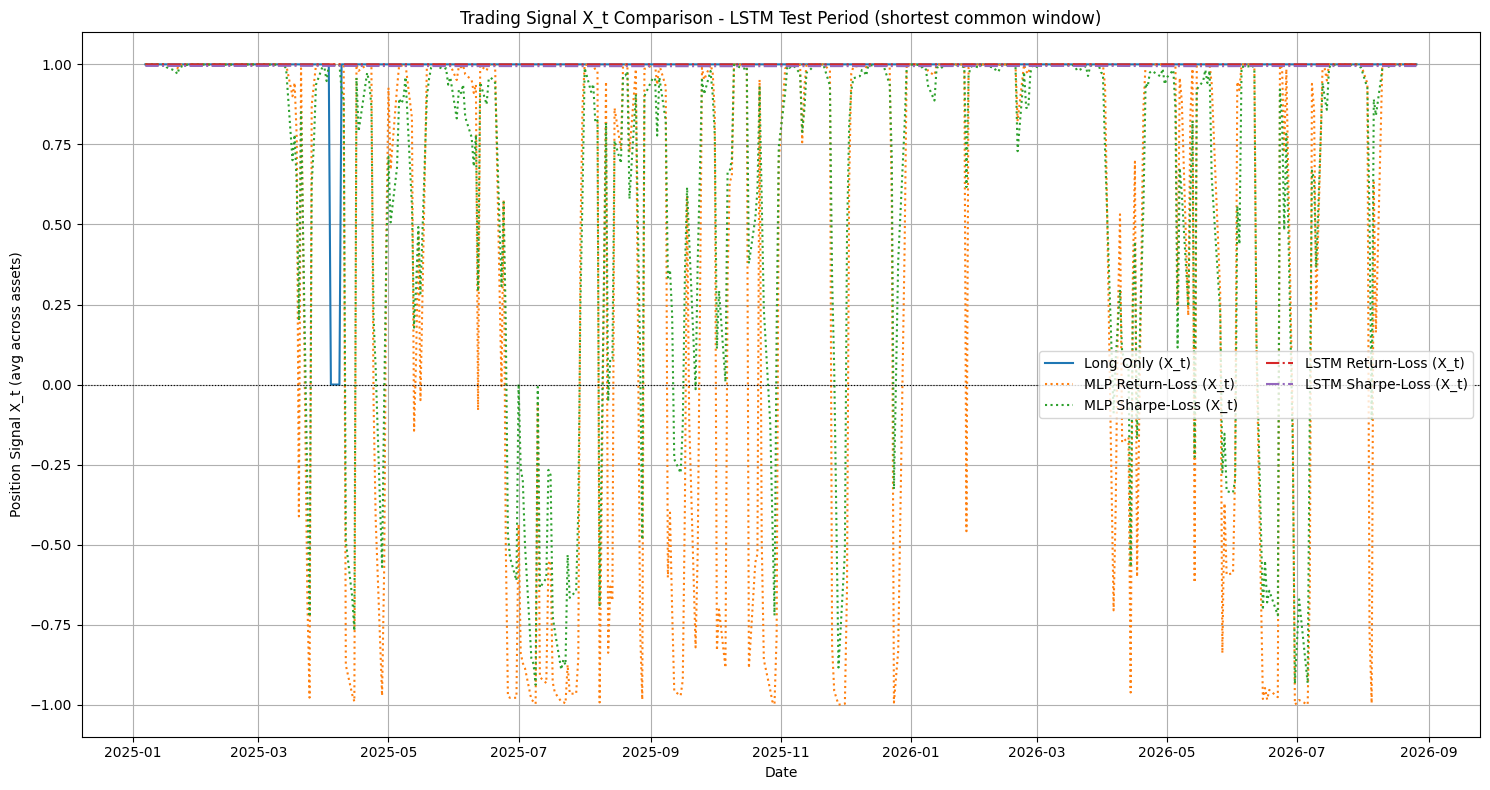

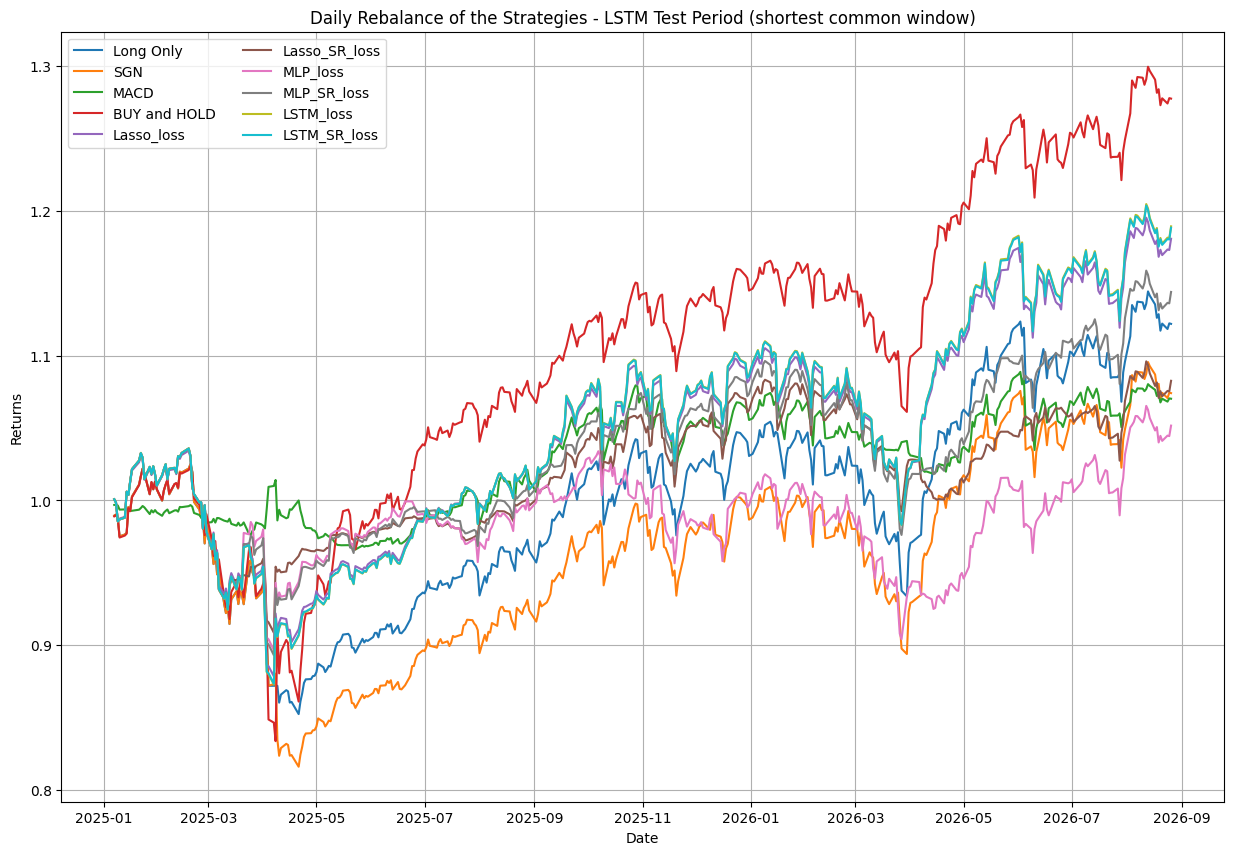

In [164]:
# Summary comparison across all strategies, restricted to the LSTM test period (the shortest,
# since create_sequences needs seq_length lookback points before it can produce a prediction).
# Aligning every series to test_dates_lstm keeps the comparison apples-to-apples.

test_dates = features_or.index[train_size + val_size:]
test_dates_lstm = test_dates[seq_length - 1:]

long = functions.TSMOM_daily(returns, data, trading_str='LONG')
sgn = functions.TSMOM_daily(returns, data, trading_str='SGN')
macd = functions.TSMOM_daily(returns, data, trading_str='MACD')
buy_and_hold = returns.mean(axis=1)

avg_Lasso_loss_series = pd.Series(avg_Lasso_loss, index=test_dates)
avg_lasso_sr_series = pd.Series(avg_lasso_sr, index=test_dates)
avg_mlp_loss_series = pd.Series(avg_TSMOM, index=test_dates)
avg_mlp_sr_series = pd.Series(avg_TSMOM_sr, index=test_dates)
avg_lstm_loss_series = pd.Series(avg_TSMOM_lstm, index=test_dates_lstm)
avg_lstm_sr_series = pd.Series(avg_TSMOM_lstm_sr, index=test_dates_lstm)

# --- Restrict every strategy to the common LSTM test period ---
common_test_index = test_dates_lstm.intersection(long.index)

long_select = long.loc[common_test_index]
sgn_selected = sgn.loc[common_test_index]
macd_selected = macd.loc[common_test_index]
buy_and_hold_selected = buy_and_hold.loc[common_test_index]
lasso_loss_selected = avg_Lasso_loss_series.loc[common_test_index]
lasso_sr_selected = avg_lasso_sr_series.loc[common_test_index]
TSMOM_mlp_loss_selected = avg_mlp_loss_series.loc[common_test_index]
TSMOM_mlp_sr_selected = avg_mlp_sr_series.loc[common_test_index]
TSMOM_lstm_loss_selected = avg_lstm_loss_series.loc[common_test_index]
TSMOM_lstm_sr_selected = avg_lstm_sr_series.loc[common_test_index]

# --- Trade signal X_t comparison over the common test period ---
X_long_test = functions.long(returns).reindex(common_test_index).dropna(how='all')
# X_sgn_test = functions.SGN(returns).reindex(common_test_index).dropna(how='all')
# X_macd_test = functions.calculate_cta_momentum_signal(data).reindex(common_test_index).dropna(how='all')
lasso_loss_signal_df = pd.DataFrame(pred_signal_lasso_loss, index=test_dates, columns=returns.columns).loc[common_test_index]
lasso_sr_signal_df = pd.DataFrame(pred_signal_lasso_SR, index=test_dates, columns=returns.columns).loc[common_test_index]
mlp_loss_signal_df = pd.DataFrame(signal_mlp, index=test_dates, columns=returns.columns).loc[common_test_index]
mlp_sr_signal_df = pd.DataFrame(signal_mlp_sr, index=test_dates, columns=returns.columns).loc[common_test_index]
lstm_loss_signal_df = pd.DataFrame(signal_mlp_lstm, index=test_dates_lstm, columns=returns.columns).loc[common_test_index]
lstm_sr_signal_df = pd.DataFrame(signal_mlp_lstm_sr, index=test_dates_lstm, columns=returns.columns).loc[common_test_index]

plt.figure(figsize=(15, 8))
plt.plot(X_long_test.mean(axis=1), label='Long Only (X_t)')
# plt.plot(X_sgn_test.mean(axis=1), label='SGN (X_t)')
# plt.plot(X_macd_test.mean(axis=1), label='MACD (X_t)')
# plt.plot(lasso_loss_signal_df.mean(axis=1), label='Lasso Return-Loss (X_t)', linestyle='--')
# plt.plot(lasso_sr_signal_df.mean(axis=1), label='Lasso Sharpe-Loss (X_t)', linestyle='--')
plt.plot(mlp_loss_signal_df.mean(axis=1), label='MLP Return-Loss (X_t)', linestyle=':')
plt.plot(mlp_sr_signal_df.mean(axis=1), label='MLP Sharpe-Loss (X_t)', linestyle=':')
plt.plot(lstm_loss_signal_df.mean(axis=1), label='LSTM Return-Loss (X_t)', linestyle='-.')
plt.plot(lstm_sr_signal_df.mean(axis=1), label='LSTM Sharpe-Loss (X_t)', linestyle='-.')
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.xlabel('Date')
plt.ylabel('Position Signal X_t (avg across assets)')
plt.title('Trading Signal X_t Comparison - LSTM Test Period (shortest common window)')
plt.legend(ncol=2)
plt.grid()
plt.tight_layout()
plt.show()

# --- Cumulative returns comparison over the same common LSTM test period ---
plt.figure(figsize=(15, 10))
plt.plot(long_select.index, (long_select + 1).cumprod(), label='Long Only')
plt.plot(sgn_selected.index, (sgn_selected + 1).cumprod(), label='SGN')
plt.plot(macd_selected.index, (macd_selected + 1).cumprod(), label='MACD')
plt.plot(buy_and_hold_selected.index, (buy_and_hold_selected + 1).cumprod(), label='BUY and HOLD')
plt.plot(lasso_loss_selected.index, (lasso_loss_selected + 1).cumprod(), label='Lasso_loss')
plt.plot(lasso_sr_selected.index, (lasso_sr_selected + 1).cumprod(), label='Lasso_SR_loss')
plt.plot(TSMOM_mlp_loss_selected.index, (TSMOM_mlp_loss_selected + 1).cumprod(), label='MLP_loss')
plt.plot(TSMOM_mlp_sr_selected.index, (TSMOM_mlp_sr_selected + 1).cumprod(), label='MLP_SR_loss')
plt.plot(TSMOM_lstm_loss_selected.index, (TSMOM_lstm_loss_selected + 1).cumprod(), label='LSTM_loss')
plt.plot(TSMOM_lstm_sr_selected.index, (TSMOM_lstm_sr_selected + 1).cumprod(), label='LSTM_SR_loss')

plt.title('Daily Rebalance of the Strategies - LSTM Test Period (shortest common window)')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.grid()
plt.legend(ncol=2)
plt.show()


In [30]:
# %%
# Building the Dataframe for the Performance Metrics 
performance_metrics = {
    "Strategy": ['Long Only', "Long+Short", "MACD", "Buy+Hold", "Lass+Loss", "Lass+Loss_SR", "MLP+Loss", "MLP+Loss_SR","LSTM+Loss", "LSTM+Loss_SR"],

    "E[Return]": [long_select.mean()*252*100, sgn_selected.mean()*252*100, macd_selected.mean()* 252*100, buy_and_hold_selected.mean()*252*100, lasso_loss_selected.mean()*252*100,
                  lasso_sr_selected.mean()*252*100, TSMOM_mlp_loss_selected.mean()*252*100, TSMOM_mlp_sr_selected.mean()* 252*100, TSMOM_lstm_loss_selected.mean() * 252*100, TSMOM_lstm_sr_selected.mean()* 252*100],

    "Vol.": [long_select.std() * np.sqrt(252)*100, sgn_selected.std() * np.sqrt(252)*100, macd_selected.std() * np.sqrt(252)*100, buy_and_hold_selected.std() * np.sqrt(252)*100, lasso_loss_selected.std()* np.sqrt(252)*100,
             lasso_sr_selected.std()*np.sqrt(252)*100, TSMOM_mlp_loss_selected.std() * np.sqrt(252)*100, TSMOM_mlp_sr_selected.std() * np.sqrt(252)*100, TSMOM_lstm_loss_selected.std() * np.sqrt(252)*100, TSMOM_lstm_sr_selected.std()* np.sqrt(252)*100], 

    "Sharp Ratio": [functions.sharp_ratio(long_select), functions.sharp_ratio(sgn_selected), functions.sharp_ratio(macd_selected), functions.sharp_ratio(buy_and_hold_selected), functions.sharp_ratio(lasso_loss_selected), 
                    functions.sharp_ratio(lasso_sr_selected), functions.sharp_ratio(TSMOM_mlp_loss_selected), functions.sharp_ratio(TSMOM_mlp_sr_selected), functions.sharp_ratio(TSMOM_lstm_loss_selected),
                    functions.sharp_ratio(TSMOM_lstm_sr_selected)], 

    "Downside Deviation": [functions.downside_deviation(long_select) * np.sqrt(252)*100, functions.downside_deviation(sgn_selected) * np.sqrt(252)*100, functions.downside_deviation(macd_selected) * np.sqrt(252)*100, functions.downside_deviation(buy_and_hold_selected) * np.sqrt(252)*100, 
                           functions.downside_deviation(lasso_loss_selected) * np.sqrt(252)*100, functions.downside_deviation(lasso_sr_selected) * np.sqrt(252)*100, 
                           functions.downside_deviation(TSMOM_mlp_loss_selected) * np.sqrt(252) *100, functions.downside_deviation(TSMOM_mlp_sr_selected)* np.sqrt(252) *100, functions.downside_deviation(TSMOM_lstm_loss_selected)* np.sqrt(252)*100, 
                           functions.downside_deviation(TSMOM_lstm_sr_selected) * np.sqrt(252)*100],

    "Sortino Ratio": [functions.sortino_ratio(long_select, MAR=0), functions.sortino_ratio(sgn_selected, MAR=0), functions.sortino_ratio(macd_selected, MAR=0), functions.sortino_ratio(buy_and_hold_selected, MAR=0), 
                      functions.sortino_ratio(lasso_loss_selected, MAR=0), functions.sortino_ratio(lasso_sr_selected, MAR=0), 
                      functions.sortino_ratio(TSMOM_mlp_loss_selected, MAR=0), functions.sortino_ratio(TSMOM_mlp_sr_selected, MAR=0), functions.sortino_ratio(TSMOM_lstm_loss_selected, MAR=0),
                      functions.sortino_ratio(TSMOM_lstm_sr_selected, MAR=0)], 

    "% of positive return": [functions.per_positive_return(long_select), functions.per_positive_return(sgn_selected), functions.per_positive_return(macd_selected),functions.per_positive_return(buy_and_hold_selected), 
                             functions.per_positive_return(lasso_loss_selected), functions.per_positive_return(lasso_sr_selected), 
                             functions.per_positive_return(TSMOM_mlp_loss_selected), functions.per_positive_return(TSMOM_mlp_sr_selected), functions.per_positive_return(TSMOM_lstm_loss_selected),
                             functions.per_positive_return(TSMOM_lstm_sr_selected)]}

# Create the DataFrame and round the values to 2 decimal places
df_performance_metrics = pd.DataFrame(performance_metrics).round(2)
df_performance_metrics


,Strategy,E[Return],Vol.,Sharp Ratio,Downside Deviation,Sortino Ratio,% of positive return
0,Long Only,8.13,14.78,0.55,16.33,0.50,54.13
1,Long+Short,5.55,15.35,0.36,17.37,0.32,54.61
2,MACD,4.58,9.28,0.49,9.91,0.46,50.97
3,Buy+Hold,16.40,16.96,0.97,16.83,0.97,54.37
4,Lass+Loss,11.22,14.60,0.77,15.51,0.72,54.61
5,Lass+Loss_SR,5.57,12.03,0.46,12.40,0.45,53.40
6,MLP+Loss,4.12,14.43,0.29,15.02,0.27,52.18
7,MLP+Loss_SR,9.15,13.65,0.67,14.48,0.63,55.10
8,LSTM+Loss,11.77,15.32,0.77,16.27,0.72,54.61
9,LSTM+Loss_SR,11.71,15.24,0.77,16.19,0.72,54.61
